In [813]:
import re
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
import shap
from scipy.stats import linregress
from tqdm import tqdm
import plotly.graph_objects as go
from datetime import timedelta
from plotly.subplots import make_subplots
import swifter
import plotly.express as px

In [764]:
# Load dataset
# df = pd.read_csv('shanta_processed_data.csv')
df = pd.read_excel("site_leaching_data.xlsx", sheet_name=0)

# Clean column names: strip whitespace and unify format
def clean_column_name(col):
	col = col.strip()
	col = re.sub(r'\s+', '_', col)
	col = re.sub(r'[^\w\d_]', '', col)
	# Remove double underscores
	col = re.sub(r'__+', '_', col)
	# Convert to lowercase
	col = col.lower()
	# Capitablize first letter and each letter after an underscore
	col = col.replace('_', ' ').title().replace(' ', '_')
	return col

df.columns = [clean_column_name(col) for col in df.columns]

In [ ]:
# Constants for the training & modeling process
random_seed = 13				# random seed for reproducibility
test_sample_size = 0.2			# proportion of data to use for testing
bin_precision = 1				# precision for binning continuous variables

# Cyanide leaching parameters

do_smoothing_window = 45		# smoothing window in days for dissolved oxygen data
# Set CN bounds
cn_lower_bound = 200  			# lower bound for cyanide concentration in ppm
cn_upper_bound = 500  			# upper bound for cyanide concentration in ppm
penalty_threshold = 450  		# where overdose penalty kicks in
penalty_weight = 0.5     		# USD per excess ppm * t
do_lower_bound = 6.0  			# lower bound for dissolved oxygen in ppm
do_upper_bound = 20.0  			# upper bound for dissolved oxygen in ppm

# Feed charateristics
ultra_fine_sizing = 50	 		# midpoint for < 75 µm sizing
fine_sizing = 112.5				# midpoint for > 75 µm sizing
coarse_sizing = 175 			# midpoint for > 150 µm sizing

# Economic constants
GOLD_PRICE_USD_PER_G = 89.24
NACN_PRICE_USD_PER_KG = 17.00
DO_PRICE_USD_PER_PPM_T = 0.002 	# USD per ppm per tonne


In [766]:
# --- Clean and impute dissolved oxygen (DO) profile ---
o2_col = "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"

# Replace zero with NaN
df[o2_col] = df[o2_col].replace(0.0, np.nan)

# Impute using a rolling median (or fallback to overall median)
df[o2_col + "_Imputed"] = df[o2_col].fillna(
	df[o2_col].rolling(window=3, min_periods=1, center=True).median()
)

df["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"] = (
	df["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"]
	.rolling(window=do_smoothing_window, min_periods=1, center=True)
	.mean()
)

# Fallback for any remaining NaNs (start/end of window)
df[o2_col + "_Imputed"] = df[o2_col + "_Imputed"].fillna(df[o2_col].median())

# --- Standardise feed grade and throughput column names ---
df["Leach_Feed_Grade_Au_Gt"] = df["Leach_Feed_Grade_Au_Gt_Day"]

# Standardise particle size fields
df = df.rename(columns={
	"Leach_Feed_Gt_150Μm_Day": "Leach_Feed_Gt_150um_Day",
	"Leach_Feed_Gt_75Μm_Day": "Leach_Feed_Gt_75um_Day",
	"Leach_Feed_Lt_75Μm_Day": "Leach_Feed_Lt_75um_Day"
})

# Ensure datetime is parsed
df["Date"] = pd.to_datetime(df["Date"])


# --- Create Interaction terms ---
size_sum = (
		df["Leach_Feed_Lt_75um_Day"] +
		df["Leach_Feed_Gt_75um_Day"] +
		df["Leach_Feed_Gt_150um_Day"]
	)
df["Fines_Fraction"] = df["Leach_Feed_Lt_75um_Day"] / size_sum.replace(0, np.nan)
df["Grade_x_Fines"] = df["Leach_Feed_Grade_Au_Gt_Day"] * df["Fines_Fraction"]

# Calculate Effective Particle Size (um)
def get_effective_particle_size(row):
	total = (
		row["Leach_Feed_Lt_75um_Day"] +
		row["Leach_Feed_Gt_75um_Day"] +
		row["Leach_Feed_Gt_150um_Day"]
	)
	if total == 0:
		return np.nan
	weighted_d = (
		row["Leach_Feed_Lt_75um_Day"] * ultra_fine_sizing +
		row["Leach_Feed_Gt_75um_Day"] * fine_sizing +
		row["Leach_Feed_Gt_150um_Day"] * coarse_sizing
	) / total
	return weighted_d

df["Effective_Particle_Size_um"] = df.apply(get_effective_particle_size, axis=1)

# Calculate Au Recovery %
df["Recovery"] = (
	(df["Cil_Feed_Total_Au_Grams"] - df["Total_Au_Tailing_Grams"])
	/ df["Cil_Feed_Total_Au_Grams"]
) * 100

# --- Standardise particle size fields ---
df = df.rename(columns={
	"Cil_Feed_Total_Au_Grams": "Au_Feed_Grams",
	"Total_Au_Tailing_Grams": "Au_Tailings_Grams",
	"Cn_Conc_Tailing_Ppm": "CN_Tailings_Concentration",
	"Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth": "Dissolved_Oxygen",
	"Effective_Particle_Size_um": "Particle_Size",
	"Cyanide_Profile_Ppm_Leach_Tank_1": "CN_Concentration",
	"Leach_Feed_Grade_Au_Gt_Day": "Au_Grade",
	"Daily_Milledtreated_Tons": "Tonnes_Processed",
})

In [767]:
features = [
	"Grade_x_Fines",
	"Particle_Size",
	"Dissolved_Oxygen",
	"CN_Concentration",
]

target = "Recovery"

In [768]:
df_model = df[features + [target]].dropna()
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_sample_size,
													random_state=random_seed)

# Train model
model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1)
model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [769]:
# Predict and evaluate
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
r2 = model.score(X_test, y_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))

# Print evaluation metrics
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R^2 Score: {r2:.4f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

Mean Absolute Error: 0.43
R^2 Score: 0.9670
Root Mean Squared Error: 0.56


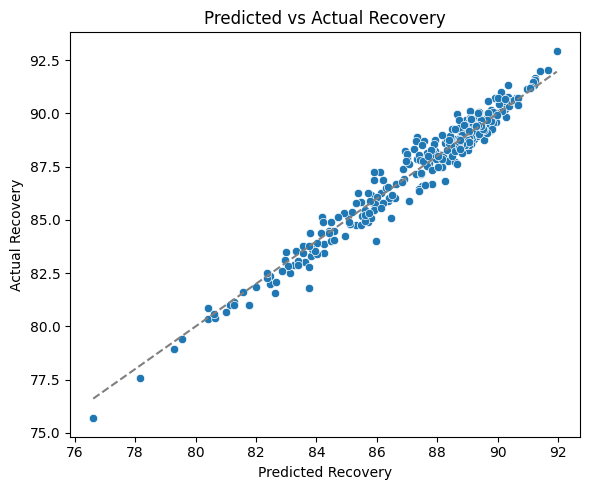

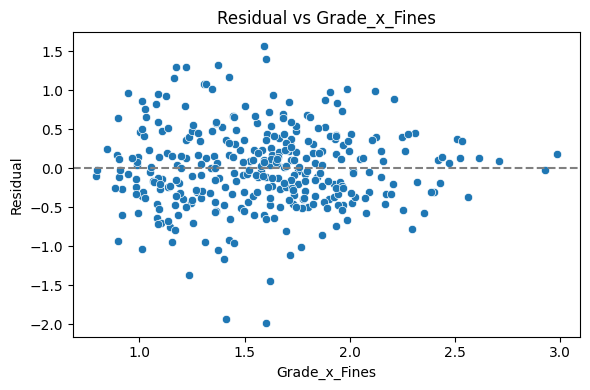

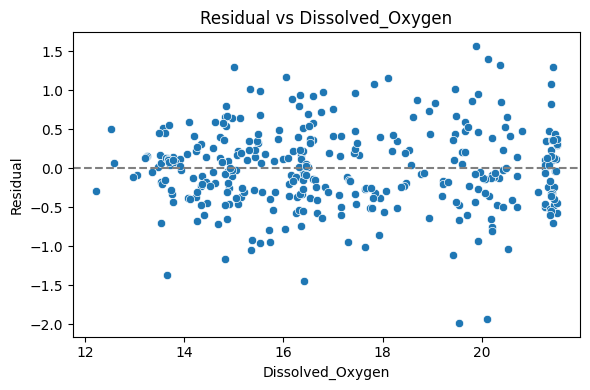

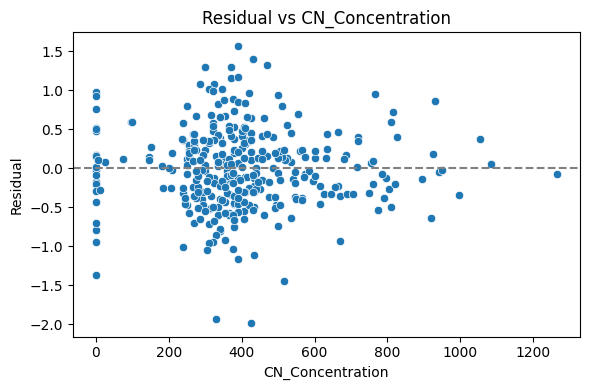

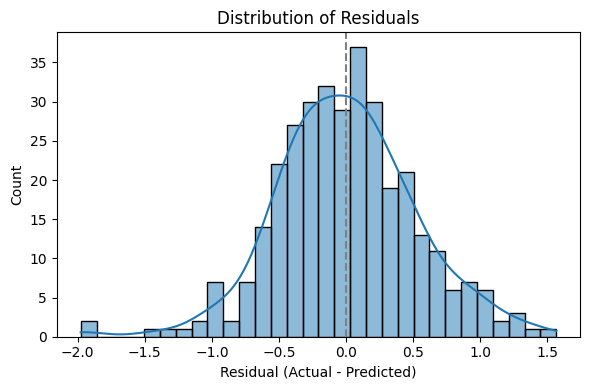

In [770]:
# Predict using trained model
df_model["Predicted_Recovery"] = model.predict(X)
df_model["Residual"] = df_model[target] - df_model["Predicted_Recovery"]

# Plot 1: Actual vs Predicted
plt.figure(figsize=(6, 5))
sns.scatterplot(x="Predicted_Recovery", y=target, data=df_model)
plt.plot([df_model["Predicted_Recovery"].min(), df_model["Predicted_Recovery"].max()],
		 [df_model["Predicted_Recovery"].min(), df_model["Predicted_Recovery"].max()],
		 linestyle='--', color='grey')
plt.xlabel("Predicted Recovery")
plt.ylabel("Actual Recovery")
plt.title("Predicted vs Actual Recovery")
plt.tight_layout()
plt.show()

# Plot 2: Residuals vs Key Features
for col in ["Grade_x_Fines",
			"Dissolved_Oxygen",
			"CN_Concentration"]:
	plt.figure(figsize=(6, 4))
	sns.scatterplot(x=col, y="Residual", data=df_model)
	plt.axhline(0, color='grey', linestyle='--')
	plt.title(f"Residual vs {col}")
	plt.tight_layout()
	plt.show()

# Plot 3: Histogram of residuals
plt.figure(figsize=(6, 4))
sns.histplot(df_model["Residual"], kde=True, bins=30)
plt.axvline(0, color='grey', linestyle='--')
plt.title("Distribution of Residuals")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

# Copy the predicted values and residual to the original DataFrame
df["Predicted_Recovery"] = df_model["Predicted_Recovery"]

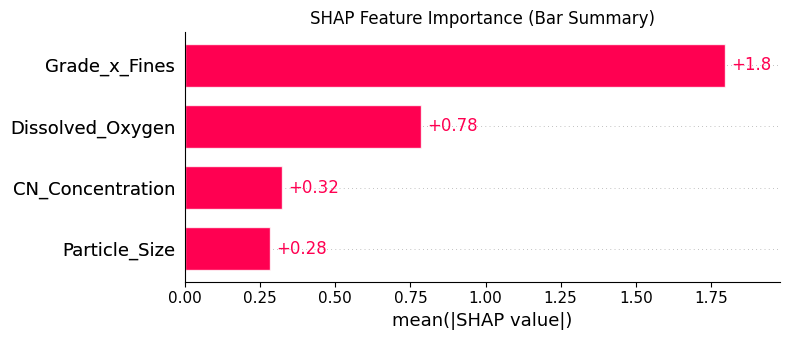

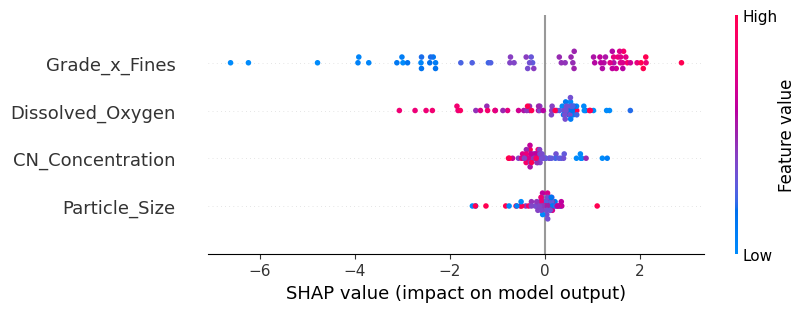

Grade_x_Fines       0.622
Dissolved_Oxygen    0.223
Particle_Size       0.078
CN_Concentration    0.076
dtype: float32

In [771]:
# Create importance Series
feature_importance = pd.Series(
	model.feature_importances_,
	index=features
).sort_values(ascending=False)

# Create SHAP explainer and compute SHAP values
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Plot summary of SHAP values (bar + beeswarm)
plt.figure(figsize=(10, 5))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("SHAP Feature Importance (Bar Summary)")
plt.tight_layout()
plt.show()

# Plot Beeswarm summary for detailed distribution
shap.plots.beeswarm(shap_values, max_display=15)

# Display feature importance to 2 decimal places
feature_importance = feature_importance.round(3)
feature_importance


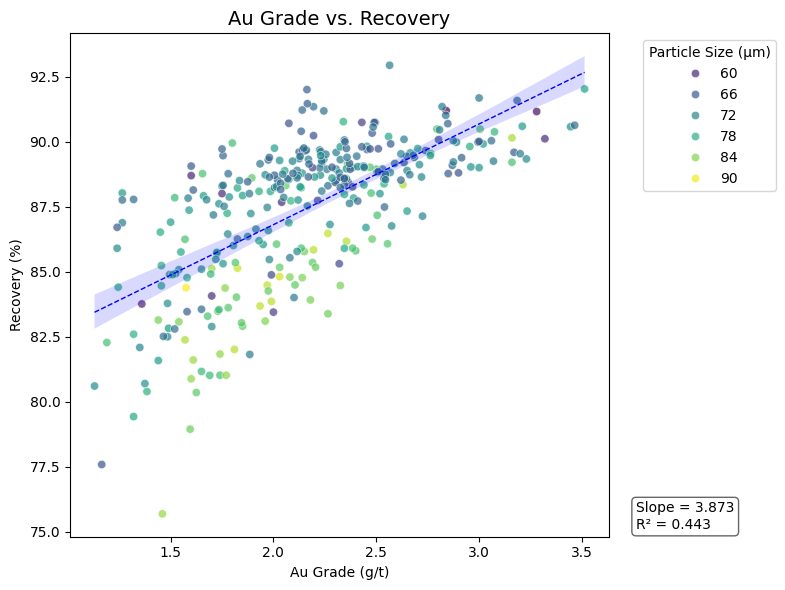

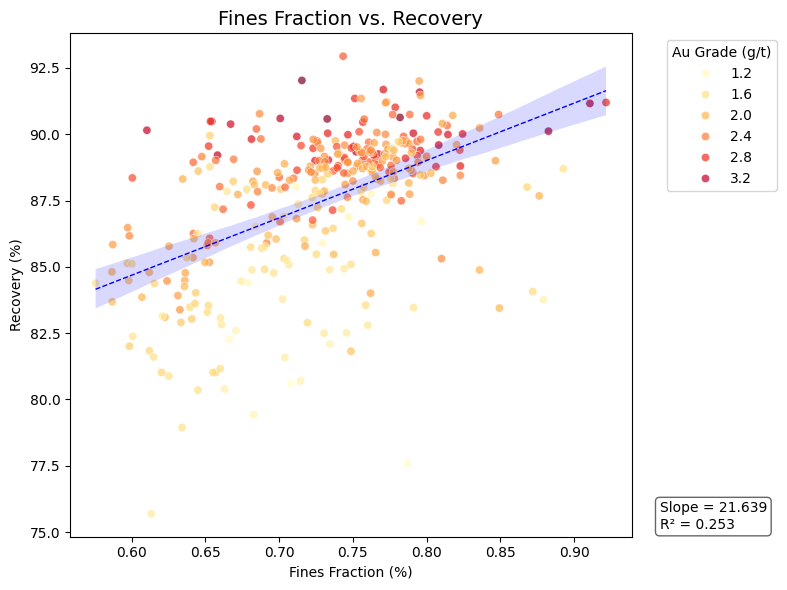

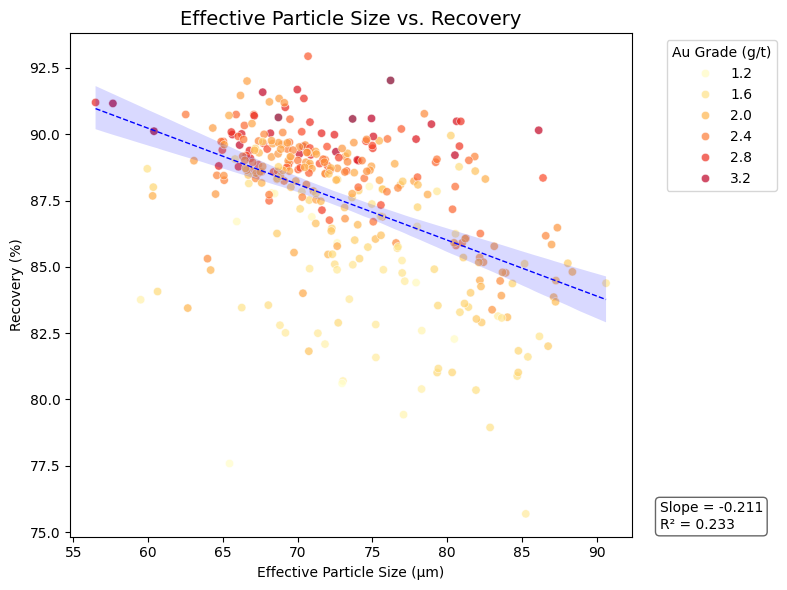

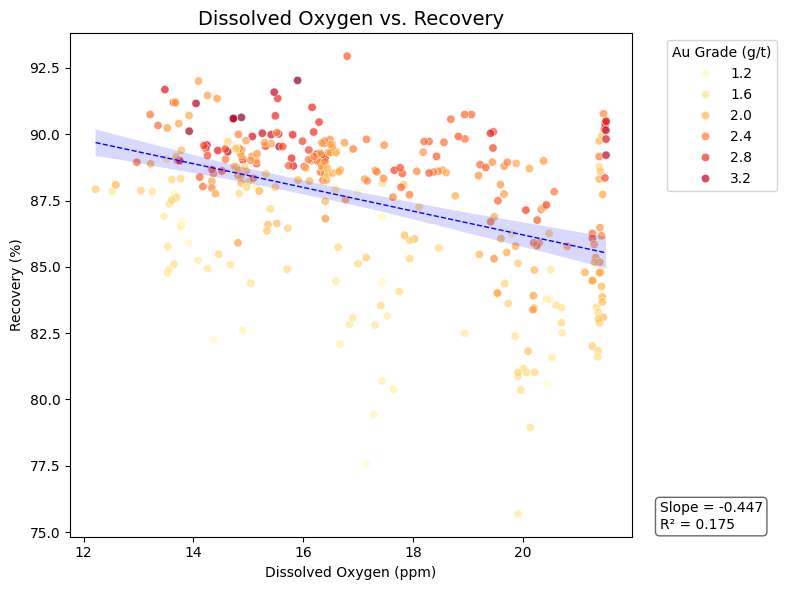

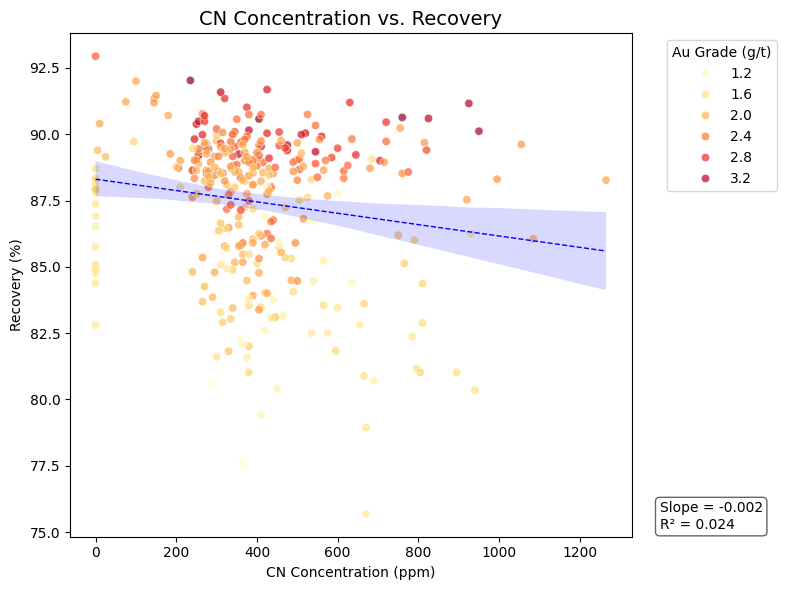

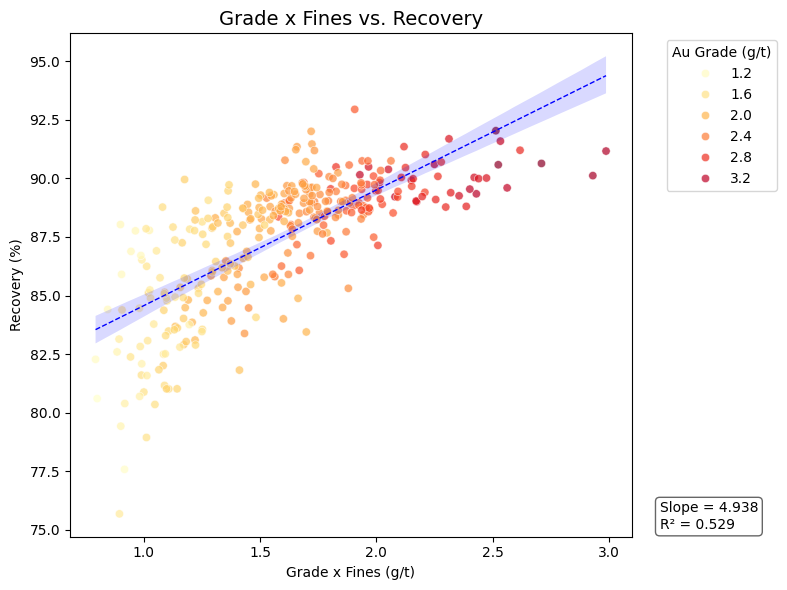

In [772]:
# Plot scatter plot for interaction between Effective Particle Size and Au Recovery

def scatter_plot_trend_hue(df, x_col, y_col, hue_col="Au_Grade", hue_title="Au Grade (g/t)",
						   title: str = "Scatter Plot with Regression Line",
						   xlabel: str = "X", ylabel: str = "Y", palette: str = "YlOrRd"):
	"""
	Plot scatter plot with regression line and show regression slope as a text box.
	"""
	# Calculate regression line
	slope, intercept, r_value, p_value, std_err = linregress(df[x_col], df[y_col])
	reg_text = f"Slope = {slope:.3f}\nR² = {r_value**2:.3f}"

	# Create plot
	plt.figure(figsize=(8, 6))
	sns.scatterplot(x=x_col, y=y_col, data=df,
					hue=hue_col, palette=palette, alpha=0.7)
	sns.regplot(x=x_col, y=y_col, data=df,
				scatter=False, color='blue', line_kws={"linestyle": "--", "linewidth": 1})

	# Add regression info box
	plt.text(1.05, 0.07, reg_text, transform=plt.gca().transAxes,
			 fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round',
													facecolor='white', alpha=0.6))

	# Final plot styling
	plt.title(title, fontsize=14)
	plt.xlabel(xlabel)
	plt.ylabel(ylabel)
	plt.legend(title=hue_title, bbox_to_anchor=(1.05, 1), loc='upper left')
	plt.tight_layout()
	plt.show()


# Call the function to plot Effective Particle Size vs. Recovery
scatter_plot_trend_hue(df, "Au_Grade", target, hue_col="Particle_Size",
					   title="Au Grade vs. Recovery", hue_title="Particle Size (µm)",
					   xlabel="Au Grade (g/t)", ylabel="Recovery (%)", palette="viridis")

scatter_plot_trend_hue(df, "Fines_Fraction", target, hue_col="Au_Grade",
					   title="Fines Fraction vs. Recovery",
					   xlabel="Fines Fraction (%)", ylabel="Recovery (%)")

scatter_plot_trend_hue(df, "Particle_Size", target, hue_col="Au_Grade",
					   title="Effective Particle Size vs. Recovery",
					   xlabel="Effective Particle Size (µm)", ylabel="Recovery (%)")

scatter_plot_trend_hue(df, "Dissolved_Oxygen", target, hue_col="Au_Grade",
					   title="Dissolved Oxygen vs. Recovery",
					   xlabel="Dissolved Oxygen (ppm)", ylabel="Recovery (%)")

scatter_plot_trend_hue(df, "CN_Concentration", target, hue_col="Au_Grade",
					   title="CN Concentration vs. Recovery",
					   xlabel="CN Concentration (ppm)", ylabel="Recovery (%)")

scatter_plot_trend_hue(df, "Grade_x_Fines", target, hue_col="Au_Grade",
					   title="Grade x Fines vs. Recovery",
					   xlabel="Grade x Fines (g/t)", ylabel="Recovery (%)")

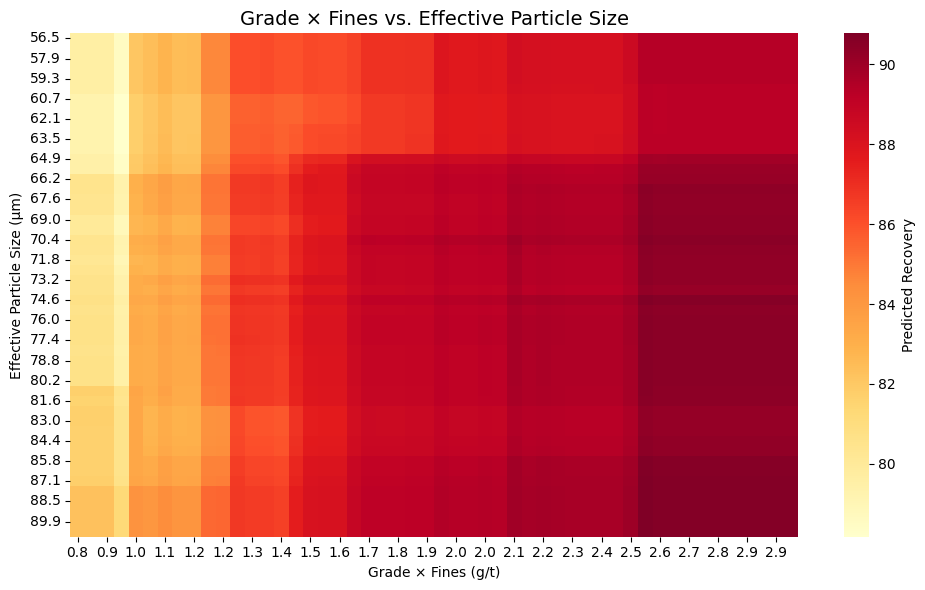

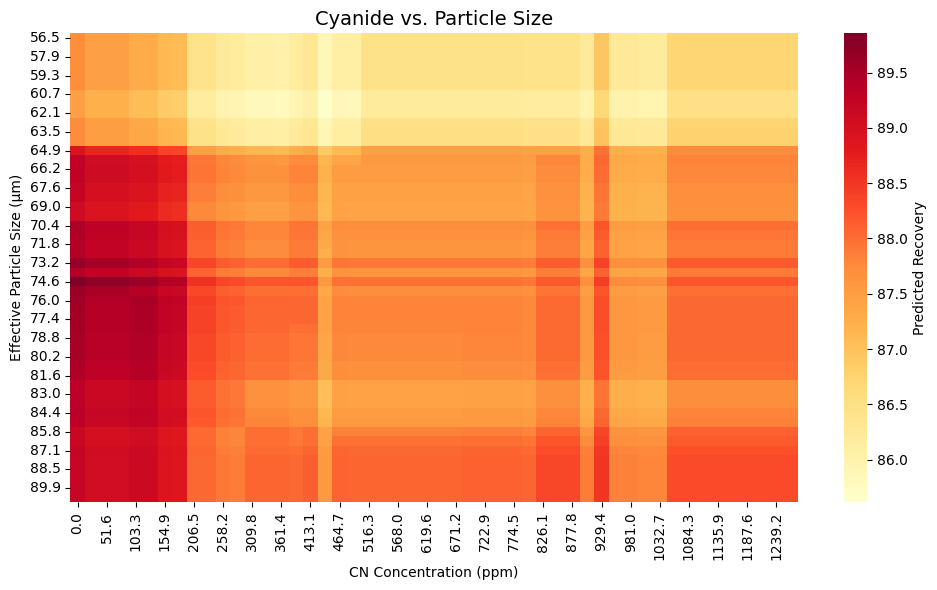

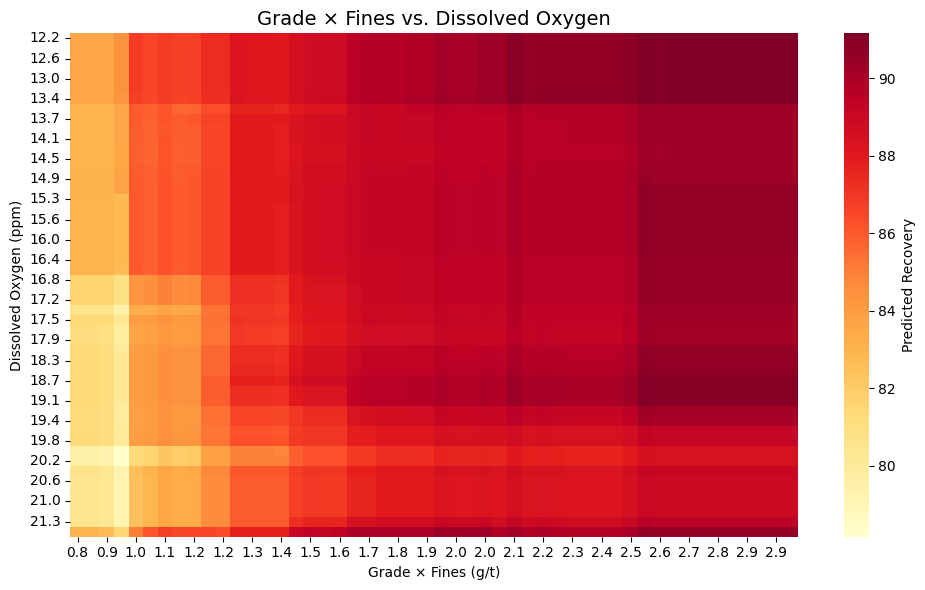

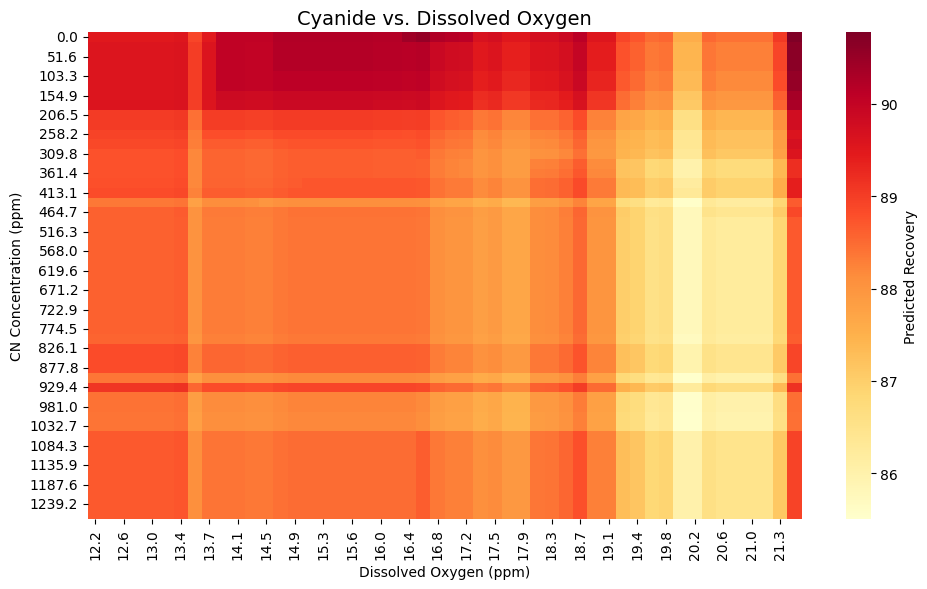

In [773]:
def plot_interaction_heatmap(model, X, var_x, var_y, fixed_vars=None,
							  grid_size=50, xlabel=None, ylabel=None,
							  title=None, cmap="YlOrRd", vmin=None, vmax=None,
							  return_data=False):
	"""
	Plot a 2D interaction heatmap between two variables using a trained model.

	Parameters:
	- model: trained predictive model (e.g., XGBoost)
	- X: reference DataFrame with feature columns
	- var_x: name of variable for x-axis
	- var_y: name of variable for y-axis
	- fixed_vars: optional dict of {feature_name: fixed_value} for other features
	- grid_size: resolution of the grid (default: 50x50)
	- xlabel, ylabel: optional axis labels
	- title: plot title
	- cmap: colour map for heatmap
	- vmin, vmax: optional fixed colour scale range
	"""
	# Define ranges for x and y
	x_range = np.linspace(X[var_x].min(), X[var_x].max(), grid_size)
	y_range = np.linspace(X[var_y].min(), X[var_y].max(), grid_size)

	# Build interaction grid
	grid = []
	for x in x_range:
		for y in y_range:
			row = {var_x: x, var_y: y}
			for col in X.columns:
				if col not in row:
					if fixed_vars and col in fixed_vars:
						row[col] = fixed_vars[col]
					else:
						row[col] = X[col].mean()
			grid.append(row)

	grid_df = pd.DataFrame(grid)
	grid_df = grid_df[X.columns]  # Ensure correct order

	# Predict
	grid_df["Predicted_Recovery"] = model.predict(grid_df)

	# Pivot for heatmap
	heatmap_df = grid_df.pivot(index=var_y, columns=var_x, values="Predicted_Recovery")

	# Round indices and columns for better readability
	heatmap_df.index = np.round(y_range, bin_precision)
	heatmap_df.columns = np.round(x_range, bin_precision)

	# Plot
	plt.figure(figsize=(10, 6))
	sns.heatmap(heatmap_df, cmap=cmap, vmin=vmin, vmax=vmax,
				cbar_kws={'label': 'Predicted Recovery'})
	plt.title(title or f"{var_x} vs. {var_y}", fontsize=14)
	plt.xlabel(xlabel or var_x)
	plt.ylabel(ylabel or var_y)
	plt.tight_layout()
	plt.show()

	if return_data:
		return grid_df, heatmap_df  # ← return both raw + pivoted data


plot_interaction_heatmap(
	model=model,
	X=X,
	var_x="Grade_x_Fines",
	var_y="Particle_Size",
	title="Grade × Fines vs. Effective Particle Size",
	xlabel="Grade × Fines (g/t)",
	ylabel="Effective Particle Size (µm)",
)


plot_interaction_heatmap(
	model=model,
	X=X,
	var_x="CN_Concentration",
	var_y="Particle_Size",
	title="Cyanide vs. Particle Size",
	xlabel="CN Concentration (ppm)",
	ylabel="Effective Particle Size (µm)"
)

plot_interaction_heatmap(
	model=model,
	X=X,
	var_x="Grade_x_Fines",
	var_y="Dissolved_Oxygen",
	title="Grade × Fines vs. Dissolved Oxygen",
	xlabel="Grade × Fines (g/t)",
	ylabel="Dissolved Oxygen (ppm)"
)

_, heatmap_df = plot_interaction_heatmap(
	model=model,
	X=X,
	var_x="Dissolved_Oxygen",
	var_y="CN_Concentration",
	title="Cyanide vs. Dissolved Oxygen",
	xlabel="Dissolved Oxygen (ppm)",
	ylabel="CN Concentration (ppm)",
	return_data=True  # ← return heatmap_df for use later
)


In [774]:
def compare_actual_vs_modelled_heatmap(actual_df, modelled_heatmap, target_col,
									   x_col, y_col, x_bins, y_bins,
									   grade_filter_col=None, grade_value=None, grade_tol=0.05,
									   xlabel=None, ylabel=None, cmap="YlOrRd"):
	"""
	Compare actual vs modelled recovery heatmaps using binned data.

	Parameters:
	- actual_df: DataFrame with actual data
	- modelled_heatmap: pivoted DataFrame from modelled grid (same bin shape as actual)
	- target_col: column name for actual recovery
	- x_col, y_col: columns to bin and compare
	- x_bins, y_bins: list or array of bin edges for each axis
	- grade_filter_col: optional column for grade × fines band filtering
	- grade_value: value to filter on (e.g., 2.00)
	- grade_tol: tolerance around grade_value
	- xlabel, ylabel: axis labels
	- cmap: colormap for heatmaps
	"""
	# Filter to target grade band if specified
	if grade_filter_col and grade_value is not None:
		actual_df = actual_df[np.isclose(actual_df[grade_filter_col], grade_value, atol=grade_tol)].copy()

	# Bin actual data
	actual_df["X_bin"] = pd.cut(actual_df[x_col], bins=x_bins)
	actual_df["Y_bin"] = pd.cut(actual_df[y_col], bins=y_bins)

	# Calculate actual recovery averages
	actual_pivot = actual_df.groupby(["Y_bin", "X_bin"], observed=False)[target_col].mean().unstack()

	# Plot comparison
	plt.figure(figsize=(12, 5))

	plt.subplot(1, 2, 1)
	sns.heatmap(modelled_heatmap, cmap=cmap, cbar_kws={"label": "Modelled Recovery"})
	plt.title(f"Modelled Recovery" + (f" ({grade_filter_col} ≈ {grade_value})" if grade_filter_col else ""))
	plt.xlabel(xlabel or x_col)
	plt.ylabel(ylabel or y_col)

	plt.subplot(1, 2, 2)
	sns.heatmap(actual_pivot, cmap=cmap, cbar_kws={"label": "Actual Recovery"})
	plt.title(f"Actual Recovery" + (f" ({grade_filter_col} ≈ {grade_value})" if grade_filter_col else ""))
	plt.xlabel(xlabel or x_col)
	plt.ylabel(ylabel or y_col)

	plt.tight_layout()
	plt.show()

	return actual_pivot


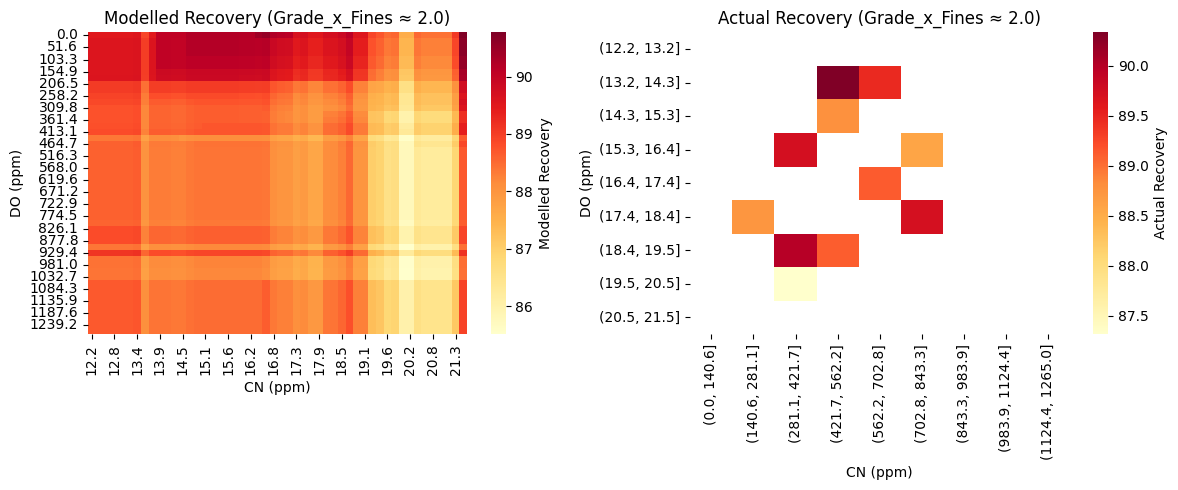

In [775]:
# Model DO and CN interaction heatmaps
do_bins = np.round(np.linspace(X["Dissolved_Oxygen"].min(), X["Dissolved_Oxygen"].max(), 10), 1)
cn_bins = np.round(np.linspace(X["CN_Concentration"].min(), X["CN_Concentration"].max(), 10), 1)

# Compare modelled vs actual
actual_pivot = compare_actual_vs_modelled_heatmap(
	actual_df=df,
	modelled_heatmap=heatmap_df,
	target_col=target,
	x_col="CN_Concentration",
	y_col="Dissolved_Oxygen",
	x_bins=cn_bins,
	y_bins=do_bins,
	grade_filter_col="Grade_x_Fines",
	grade_value=2.00,
	grade_tol=0.05,
	xlabel="CN (ppm)",
	ylabel="DO (ppm)"
)

# Compare modelled vs actual for different grade bands
# grade_bands = [1.50, 2.50, 3.00, 3.50]
# for grade in grade_bands:
# 	print(f"Comparing for Grade × Fines ≈ {grade:.2f}")
# 	actual_pivot = compare_actual_vs_modelled_heatmap(
# 		actual_df=df,
# 		modelled_heatmap=heatmap_df,
# 		target_col=target,
# 		x_col="CN_Concentration",
# 		y_col="Dissolved_Oxygen",
# 		x_bins=cn_bins,
# 		y_bins=do_bins,
# 		grade_filter_col="Grade_x_Fines",
# 		grade_value=grade,
# 		grade_tol=0.05,
# 		xlabel="CN (ppm)",
# 		ylabel="DO (ppm)"
# 	)


heatmap_df index: Index([0.0, 25.8, 51.6, 77.4, 103.3], dtype='float64')
actual_pivot index: CategoricalIndex([210.85, 351.4, 491.95, 632.5, 773.05], categories=[70.30, 210.85, 351.40, 491.95, ..., 773.05, 913.60, 1054.15, 1194.70], ordered=True, dtype='category', name='CN_mid')
Modelled shape: (5, 7)
Actual shape: (5, 7)
Delta shape: (5, 7)
NaNs in modelled: 35
NaNs in actual: 24
NaNs in delta: 35


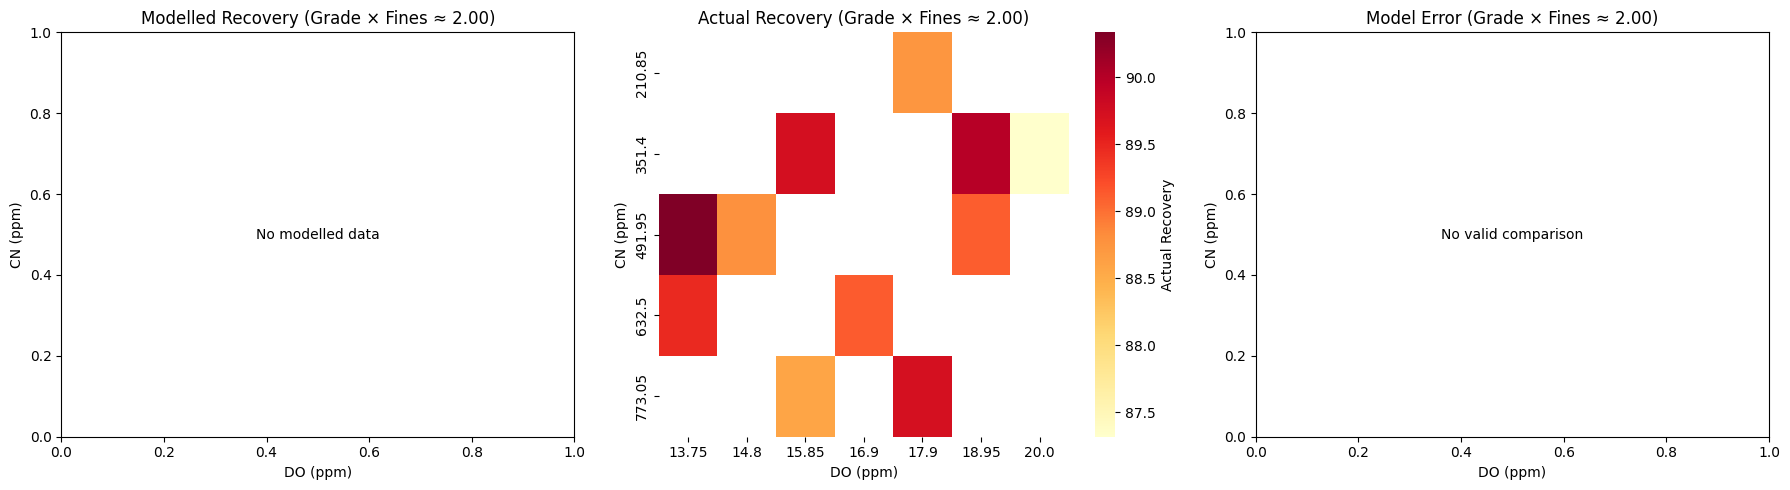

In [776]:
# Step 1: Filter actuals to target Grade x Fines ≈ 2.00
actual_band = df[np.isclose(df["Grade_x_Fines"], 2.00, atol=0.05)].copy()

# Step 2: Bin using model input variables — CN_Concentration and Dissolved_Oxygen
do_bins = np.round(np.linspace(X["Dissolved_Oxygen"].min(), X["Dissolved_Oxygen"].max(), 10), 1)
cn_bins = np.round(np.linspace(X["CN_Concentration"].min(), X["CN_Concentration"].max(), 10), 1)

actual_band["DO_bin"] = pd.cut(actual_band["Dissolved_Oxygen"], bins=do_bins)
actual_band["CN_bin"] = pd.cut(actual_band["CN_Concentration"], bins=cn_bins)

# Convert bins to midpoints **before pivoting**
actual_band["DO_mid"] = actual_band["DO_bin"].apply(lambda x: round(x.mid, 2))
actual_band["CN_mid"] = actual_band["CN_bin"].apply(lambda x: round(x.mid, 2))

# Step 3: Pivot actual recovery using midpoints
actual_pivot = actual_band.groupby(["CN_mid", "DO_mid"], observed=False)[target].mean().unstack()

# Step 4: Drop any empty rows/columns
actual_pivot = actual_pivot.dropna(how="all").dropna(axis=1, how="all")

# Step 5: Align modelled heatmap to actual midpoints
# First round modelled heatmap index/columns to same precision
heatmap_df.index = np.round(heatmap_df.index.astype(float), 2)
heatmap_df.columns = np.round(heatmap_df.columns.astype(float), 2)

# Then reindex
model_reindexed = heatmap_df.reindex(index=actual_pivot.index, columns=actual_pivot.columns)

# Step 6: Calculate delta
delta_df = model_reindexed - actual_pivot

# Step 7: Diagnostics
print("heatmap_df index:", heatmap_df.index[:5])
print("actual_pivot index:", actual_pivot.index[:5])
print("Modelled shape:", model_reindexed.shape)
print("Actual shape:", actual_pivot.shape)
print("Delta shape:", delta_df.shape)
print("NaNs in modelled:", model_reindexed.isna().sum().sum())
print("NaNs in actual:", actual_pivot.isna().sum().sum())
print("NaNs in delta:", delta_df.isna().sum().sum())

# Step 8: Plot
plt.figure(figsize=(18, 5))

# A: Modelled Recovery
plt.subplot(1, 3, 1)
if model_reindexed.notna().any().any():
	sns.heatmap(model_reindexed, cmap="YlOrRd", cbar_kws={"label": "Modelled Recovery"})
else:
	plt.text(0.5, 0.5, "No modelled data", ha='center', va='center')
plt.title("Modelled Recovery (Grade × Fines ≈ 2.00)")
plt.xlabel("DO (ppm)")
plt.ylabel("CN (ppm)")

# B: Actual Recovery
plt.subplot(1, 3, 2)
if actual_pivot.notna().any().any():
	sns.heatmap(actual_pivot, cmap="YlOrRd", cbar_kws={"label": "Actual Recovery"})
else:
	plt.text(0.5, 0.5, "No actual data", ha='center', va='center')
plt.title("Actual Recovery (Grade × Fines ≈ 2.00)")
plt.xlabel("DO (ppm)")
plt.ylabel("CN (ppm)")

# C: Delta
plt.subplot(1, 3, 3)
if delta_df.notna().any().any():
	sns.heatmap(delta_df, cmap="coolwarm", center=0, annot=True, fmt=".2f",
				cbar_kws={"label": "Model − Actual Recovery"})
else:
	plt.text(0.5, 0.5, "No valid comparison", ha='center', va='center')
plt.title("Model Error (Grade × Fines ≈ 2.00)")
plt.xlabel("DO (ppm)")
plt.ylabel("CN (ppm)")

plt.tight_layout()
plt.show()


**Reasonable engineering-based estimate for DO:**
| Input                                            | Value                       | Notes                                |
| ------------------------------------------------ | --------------------------- | ------------------------------------ |
| Air contains \~21% oxygen                        | ✅                           | Injection can be with air or pure O₂ |
| Oxygen is often injected via spargers or blowers | ✅                           | Costs driven by energy and supply    |
| Industrial O₂ price                              | \~\$0.10–0.30 per Nm³       | Depends on purity and location       |
| Nm³ O₂ required to raise DO by 1 ppm in 1 tonne  | \~0.001–0.003 Nm³/tonne/ppm | Empirical rule-of-thumb              |

So, a reasonable ballpark cost is:
> USD 0.001 to 0.005 per ppm per tonne


In [777]:
fields_to_keep = [
	'Date',
	'Au_Grade',
	'Au_Feed_Grams',
	'CN_Tailings_Concentration',
	'Au_Tailings_Grams',
	'Leach_Feed_Gt_150um_Day',
	'Leach_Feed_Gt_75um_Day',
	'Leach_Feed_Lt_75um_Day',
	'CN_Concentration',
	'Tonnes_Processed',
	'Dissolved_Oxygen',
	'Fines_Fraction',
	'Grade_x_Fines',
	'Particle_Size',
	'Recovery',
	'Predicted_Recovery'
	]

df = df[fields_to_keep].copy()

## Add Calculated Features

In [778]:
# --- Gold Revenue Calculation ---
df['Actual_Gold_Revenue'] = df['Recovery'] / 100 * df['Au_Grade'] * df['Tonnes_Processed'] * GOLD_PRICE_USD_PER_G

gold_produced = (df['Au_Feed_Grams'] - df['Au_Tailings_Grams'])
df['Alt_Gold_Revenue'] =  gold_produced * GOLD_PRICE_USD_PER_G

# --- Cyanide and Dissolved Oxygen Costs ---
df['Actual_CN_Cost'] = df['CN_Concentration'] * NACN_PRICE_USD_PER_KG / 1000 * df['Tonnes_Processed']
df['Actual_DO_Cost'] = df['Dissolved_Oxygen'] * DO_PRICE_USD_PER_PPM_T * df['Tonnes_Processed']

# --- Actual Net Value Calculation ---
df['Actual_Net_Value_USD_t'] = df['Actual_Gold_Revenue'] - df['Actual_CN_Cost'] - df['Actual_DO_Cost']

# Display the first 10 rows of the final DataFrame with rounded values
df[['Actual_Gold_Revenue', 'Actual_CN_Cost', 'Actual_DO_Cost', 
	'Actual_Net_Value_USD_t']].round(2).head(10)

,Actual_Gold_Revenue,Actual_CN_Cost,Actual_DO_Cost,Actual_Net_Value_USD_t
0,402222.03,20894.12,107.82,381220.08
1,482548.24,18263.03,107.55,464177.66
2,499016.48,18802.71,108.18,480105.59
3,446566.65,21657.97,108.41,424800.27
4,338095.91,16487.92,108.60,321499.40
5,379331.78,16281.62,108.67,362941.49
6,429769.62,18248.92,108.91,411411.80
7,405177.19,10942.38,103.64,394131.18
8,327044.40,17685.96,108.36,309250.08
9,317563.78,13402.16,108.72,304052.90


## Define Kinetic Gold Dissolution Equation

In [779]:
def calc_recovery_kinetic(cn_ppm, do_ppm, grade_gpt, particle_size_um,
						  gold_locked_fraction=0.1,
						  k_base=0.005,  # Increased from 0.0012
						  cn_exponent=0.8,
						  do_exponent=0.6,
						  liberation_factor=1.8):  # Stronger liberation sensitivity
	"""
	Returns estimated gold recovery (%) using an adjusted kinetic model.
	"""
	# Prevent unrealistic input values
	cn_ppm = max(cn_ppm, 1)
	do_ppm = max(do_ppm, 0.1)
	particle_size_um = max(particle_size_um, 1)

	# Liberation model (more sensitive)
	liberation = 1 - gold_locked_fraction * np.exp(-liberation_factor * (75 / particle_size_um))

	# Kinetic recovery curve
	k_effective = k_base * (cn_ppm ** cn_exponent) * (do_ppm ** do_exponent)
	recovery_pct = liberation * (1 - np.exp(-k_effective))

	return recovery_pct * 100


### Test the new kinetic model

In [780]:
# Grab values for testing from first 10 rows of the DataFrame
sample_df = df.head(10).copy()  # Use first 10 rows for testing

for index, row in sample_df.iterrows():
	test_sample = row
	cn = test_sample['CN_Concentration']  # ppm
	do = test_sample['Dissolved_Oxygen']  # ppm
	grade = test_sample['Au_Grade']  # g/t
	particle_size = test_sample['Particle_Size']  # microns
	recovery = calc_recovery_kinetic(cn, do, grade, particle_size)
	print(f"Kinetic Recovery: {recovery:.2f}% vs Actual: {test_sample['Recovery']:.2f}% "
		  f"Error: {recovery - test_sample['Recovery']:.2f}%")

Kinetic Recovery: 96.87% vs Actual: 84.49% Error: 12.38%
Kinetic Recovery: 96.21% vs Actual: 86.26% Error: 9.95%
Kinetic Recovery: 96.38% vs Actual: 86.08% Error: 10.30%
Kinetic Recovery: 96.94% vs Actual: 84.47% Error: 12.47%
Kinetic Recovery: 95.29% vs Actual: 82.01% Error: 13.28%
Kinetic Recovery: 95.17% vs Actual: 84.48% Error: 10.68%
Kinetic Recovery: 95.96% vs Actual: 85.84% Error: 10.12%
Kinetic Recovery: 91.62% vs Actual: 85.35% Error: 6.27%
Kinetic Recovery: 96.03% vs Actual: 83.48% Error: 12.55%
Kinetic Recovery: 93.65% vs Actual: 83.29% Error: 10.36%


### Apply Kinetic Model to Dataset

In [781]:
# Define constants
Au_price_usd_per_g = 89.24
NaCN_price_usd_per_kg = 17.0
DO_price_usd_per_kg = 0.30  # estimated
ppm_to_kg_per_t = 1 / 1_000_000 * 1_000  # convert ppm to kg/t

# Define band logic
cn_band_width = 0.15  # ±15%
do_band_width = 0.10  # ±10%

# Placeholder kinetic recovery function
def kinetic_model_recovery(grade_x_fines, particle_size, cn_ppm, do_ppm):
	# A simple tuned kinetic-like model based on prior tuning effort
	base_recovery = 50 + 0.25 * grade_x_fines
	cn_effect = 25 * (1 - np.exp(-0.005 * cn_ppm))
	do_effect = 15 * (1 - np.exp(-0.2 * do_ppm))
	size_penalty = -10 * (particle_size / 150)  # larger size reduces recovery
	return np.clip(base_recovery + cn_effect + do_effect + size_penalty, 0, 100)

# Compute optimal + bands
results = []
for _, row in df.iterrows():
	grade_x_fines = row.get("Grade_x_Fines", np.nan)
	psd = row.get("Particle_Size", np.nan)

	# Define CN and DO range for optimisation
	cn_range = np.linspace(100, 800, 100)
	do_range = np.linspace(5, 12, 50)
	best_value = -np.inf
	optimal_cn, optimal_do, optimal_recovery = None, None, None

	for cn in cn_range:
		for do in do_range:
			recovery = kinetic_model_recovery(grade_x_fines, psd, cn, do)
			gold_revenue = recovery / 100 * grade_x_fines * Au_price_usd_per_g
			nacn_cost = cn * ppm_to_kg_per_t * NaCN_price_usd_per_kg
			do_cost = do * ppm_to_kg_per_t * DO_price_usd_per_kg
			net_value = gold_revenue - nacn_cost - do_cost

			if net_value > best_value:
				best_value = net_value
				optimal_cn, optimal_do = cn, do
				optimal_recovery = recovery

	# Define upper/lower bounds
	cn_low = optimal_cn * (1 - cn_band_width)
	cn_high = optimal_cn * (1 + cn_band_width)
	do_low = optimal_do * (1 - do_band_width)
	do_high = optimal_do * (1 + do_band_width)

	results.append({
		"Optimal_CN_ppm": round(optimal_cn, 1),
		"CN_Low_ppm": round(cn_low, 1),
		"CN_High_ppm": round(cn_high, 1),
		"Optimal_DO_ppm": round(optimal_do, 2),
		"DO_Low_ppm": round(do_low, 2),
		"DO_High_ppm": round(do_high, 2),
		"Predicted_Recovery_pct": round(optimal_recovery, 2),
		"Net_Value_USD_t": round(best_value, 2)
	})

# Merge results into the original DataFrame
df_results = pd.concat([df.reset_index(drop=True), pd.DataFrame(results)], axis=1)

df_results


,Date,Au_Grade,Au_Feed_Grams,CN_Tailings_Concentration,Au_Tailings_Grams,Leach_Feed_Gt_150um_Day,Leach_Feed_Gt_75um_Day,Leach_Feed_Lt_75um_Day,CN_Concentration,Tonnes_Processed,...,Actual_DO_Cost,Actual_Net_Value_USD_t,Optimal_CN_ppm,CN_Low_ppm,CN_High_ppm,Optimal_DO_ppm,DO_Low_ppm,DO_High_ppm,Predicted_Recovery_pct,Net_Value_USD_t
0,2024-06-01,2.105,5408.537507,312.0,838.702532,15.655000,22.020000,65.858692,485,2534.15700,...,107.822749,381220.080099,432.3,367.5,497.2,12.0,10.8,13.2,80.62,88.98
1,2024-06-02,2.480,6271.254182,326.0,861.857412,15.245000,19.400000,62.117668,425,2527.75550,...,107.550379,464177.660795,467.7,397.5,537.8,12.0,10.8,13.2,81.14,107.33
2,2024-06-03,2.555,6500.057769,278.0,905.066478,15.130000,19.180000,64.551262,435,2542.62450,...,108.183022,480105.592792,481.8,409.5,554.1,12.0,10.8,13.2,81.39,112.98
3,2024-06-04,2.325,5930.170202,208.0,920.926261,16.130000,21.575000,62.579023,500,2547.99600,...,108.411568,424800.269936,453.5,385.5,521.6,12.0,10.8,13.2,80.84,96.96
4,2024-06-05,1.810,4624.567127,175.0,831.944431,18.500000,21.265000,59.298338,380,2552.30885,...,108.595070,321499.397998,389.9,331.4,448.4,12.0,10.8,13.2,79.57,70.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,2025-04-26,2.245,4780.956288,295.0,421.289114,7.960909,15.274376,78.764715,145,2127.72280,...,58.173517,383410.393984,488.9,415.6,562.2,12.0,10.8,13.2,82.30,119.00
330,2025-04-27,1.935,4884.737518,230.0,529.864335,8.615930,14.613428,78.770643,25,2523.16350,...,69.055103,387295.255133,453.5,385.5,521.6,12.0,10.8,13.2,81.79,101.36
331,2025-04-28,2.135,5359.499781,240.0,514.269847,8.182104,10.756719,81.061177,10,2508.63340,...,68.903128,431605.135596,488.9,415.6,562.2,12.0,10.8,13.2,82.44,119.01
332,2025-04-29,1.755,4441.033994,225.0,518.475504,7.378956,15.060023,77.561021,0,2529.14880,...,69.626413,349792.067443,439.4,373.5,505.3,12.0,10.8,13.2,81.63,91.68


**Compare Recovery Models**
| Feature        | **XGBoost Model**                                                        | **Kinetic Model**                                                                |
| -------------- | ------------------------------------------------------------------------ | -------------------------------------------------------------------------------- |
| **Type**       | Machine Learning (data-driven)                                           | Physics-inspired (domain-informed)                                               |
| **Trained On** | Historical plant data (`Recovery` as target)                             | Theoretical gold leaching kinetics tuned to observed outcomes                    |
| **Inputs**     | `Grade_x_Fines`, `Particle_Size`, `Dissolved_Oxygen`, `CN_Concentration` | Same inputs (with ability to expand to time, grain size, etc.)                   |
| **Output**     | Predicted `Recovery`                                                     | Predicted `Recovery`                                                             |
| **Strengths**  | Fits patterns in site data, handles unknown interactions                 | Generalises based on mechanistic behaviour, interpretable                        |
| **Weaknesses** | May overfit noise, harder to explain                                     | Can misrepresent site-specific quirks if parameters are not calibrated correctly |

#### **What We Should Assess Now**
Let’s consider the following questions to guide our comparison:

**1. Predictive Accuracy on Historical Data**
* How well do both models predict the actual recovery for the dataset?
* Plot predicted vs actual and compute RMSE / MAE.

**2. Economic Optimisation Consistency**
* Does the CN dosage recommended by each model actually lead to improved net value?
* Compare optimal CN from both approaches: is one consistently under- or over-prescribing?

**3. Visual and Behavioural Comparison**
* How does each model behave across CN and DO sweeps? (i.e. dose-response curves)
* Does the XGB model exhibit realistic saturation or diminishing returns?
* Does the kinetic model vary smoothly and predict plausible recovery curves?

In [782]:
def predict_recovery_kinetic(
	grade,
	particle_size,
	dissolved_oxygen,
	cn_concentration,
	gold_grain_size=30,  # µm
	ore_particle_shape_factor=1.5,
	k_base=0.0032,
	cn_power=0.5,
	do_power=0.3,
	size_power=1.2
):
	"""
	Estimate gold recovery (%) using a kinetic model with liberation and chemical effects.
	
	Parameters:
		grade (float): Grade x Fines proxy for exposed gold
		particle_size (float): Effective particle size (µm)
		dissolved_oxygen (float): DO concentration (ppm)
		cn_concentration (float): Cyanide concentration (ppm)
		gold_grain_size (float): Mean Au grain size (µm)
		ore_particle_shape_factor (float): Typically 1–2; adjusts liberation rate
		k_base (float): Base kinetic rate constant
		cn_power (float): Cyanide exponent
		do_power (float): DO exponent
		size_power (float): Liberation exponent for particle size

	Returns:
		recovery (float): Predicted recovery percentage (0–100)
	"""
	# Avoid divide-by-zero or negative issues
	particle_size = max(particle_size, 10)
	cn_concentration = max(cn_concentration, 1)
	dissolved_oxygen = max(dissolved_oxygen, 0.1)
	gold_grain_size = max(gold_grain_size, 1)

	# Liberation factor (based on Lima & Hodouin)
	liberation = 1 - np.exp(-(ore_particle_shape_factor * particle_size / gold_grain_size) ** size_power)

	# Kinetic rate component
	k = k_base * (cn_concentration ** cn_power) * (dissolved_oxygen ** do_power)

	# Final recovery as a function of exposed gold (grade proxy), kinetics, and liberation
	recovery = 100 * (1 - np.exp(-k * liberation * grade))

	return min(recovery, 100)


### Compare Performance of Kinetic & XBG Models

XGB -> RMSE: 0.52, MAE: 0.40
Kinetic Model -> RMSE: 67.94, MAE: 67.56


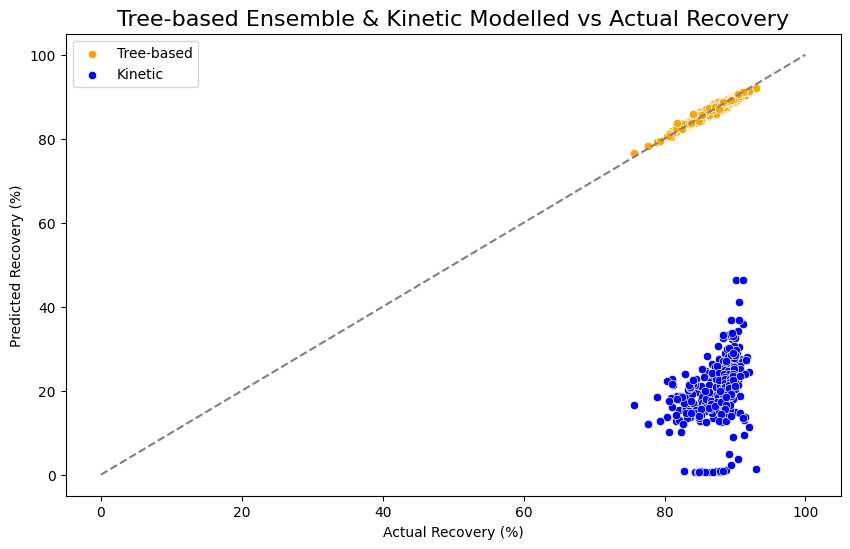

In [841]:
# Rename for clarity
df = df.rename(columns={
	"Recovery": "Actual_Recovery"
})

# Kinetic model prediction
df["Kinetic_Recovery"] = df.apply(
	lambda row: predict_recovery_kinetic(
		grade=row["Grade_x_Fines"],
		particle_size=row["Particle_Size"],
		dissolved_oxygen=row["Dissolved_Oxygen"],
		cn_concentration=row["CN_Concentration"]
	),
	axis=1
)

def evaluate_model(true, pred, label):
	rmse = np.sqrt(mean_squared_error(true, pred))
	mae = mean_absolute_error(true, pred)
	print(f"{label} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}")

evaluate_model(df["Actual_Recovery"], df["Predicted_Recovery"], "XGB")
evaluate_model(df["Actual_Recovery"], df["Kinetic_Recovery"], "Kinetic Model")

# Plot predicted vs actual recovery for both models
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Actual_Recovery", y="Predicted_Recovery", data=df,
				label="Tree-based", color="orange")
sns.scatterplot(x="Actual_Recovery", y="Kinetic_Recovery", data=df,
				label="Kinetic", color="blue")
plt.plot([0, 100], [0, 100], linestyle="--", color="gray")
plt.xlabel("Actual Recovery (%)")
plt.ylabel("Predicted Recovery (%)")
plt.title("Tree-based Ensemble & Kinetic Modelled vs Actual Recovery", fontsize=16)
plt.legend()
plt.grid(False)
plt.show()

#### 🧠 Interpretation:
| Model             | RMSE  | MAE   | Comment                                                                             |
| ----------------- | ----- | ----- | ----------------------------------------------------------------------------------- |
| **XGBoost**       | 0.52  | 0.40  | Excellent fit – tightly clustered around the 1:1 line. Predicts recovery very well. |
| **Kinetic Model** | 67.94 | 67.56 | Very poor fit – consistently underpredicting recovery across the board.             |

#### 🔍 What the plot shows:
* **Orange dots (XGBoost):** Hug the diagonal line, indicating close agreement between predicted and actual recovery values.
* **Blue dots (Kinetic):** Cluster well below the line, suggesting the model is systematically underestimating recovery — often by 60–80 percentage points.

**Diagnosis: Why the Kinetic Model Fails Here**
* Underfitting: The kinetic model is oversimplified and unable to capture all the complexities of the real process (e.g. interactions, non-linear effects, operational variability).
* Parameter Mismatch: The kinetic model parameters may not reflect actual site-specific conditions. Especially if grade, CN, DO, and particle size ranges differ from what the model assumes.
* Model Assumptions: The kinetic model assumes first-order dissolution kinetics and an exponential liberation function, which may not reflect your real ore mineralogy or operating conditions.

#### 🚩 Key Takeaway:
* **Primary Model:** Use the XGBoost model for recovery prediction, diagnostics, and recommendation logic. It provides high fidelity with site data.
* **Kinetic Model:**
	- Retain it as a theoretical baseline or sanity check.
	- Fit it better by re-tuning parameters using site data or hybridizing it with ML output.

## Simulate CN/DO grid
* Generate recovery + cost + revenue for all combinations.
* Identify optimal point and a recommended range.
* Append these to the dataframe.

For each row in the dataframe:
1. Fix Grade_x_Fines, Particle_Size (row values).
2. Simulate grid:
	* CN range = 100 to 600 ppm
	* DO range = 5 to 11 ppm\
	(e.g. 20 CN × 15 DO = 300 points per row)
3. Predict recovery for each combination.
4. Calculate:
* Revenue = Recovery × Grade × Tonnes × Gold price
* Cost = CN cost + DO cost
* Net Value = Revenue − Cost
5. Identify:
* Best CN/DO combination (max net value)
* All combinations within ±10% of best net value
6. Return:
* Recommended_CN, Recommended_DO
* CN_Min, CN_Max, DO_Min, DO_Max (for the efficient range)

### CN & DO Bounds Selection for Grid Search

In [808]:
min_cn_conc = 100 				# minimum cyanide concentration in ppm
max_cn_conc = 600 				# maximum cyanide concentration in ppm
min_do_conc = 13.0 				# minimum dissolved oxygen concentration in ppm
max_do_conc = 18.0 				# maximum dissolved oxygen concentration in ppm

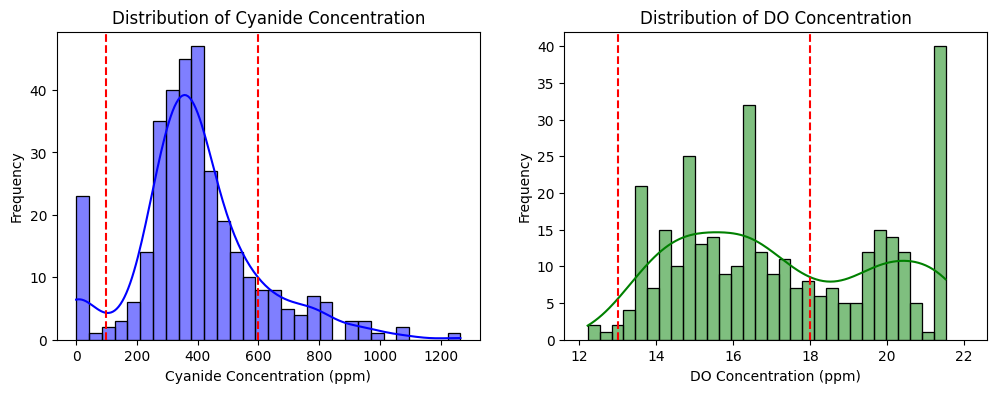

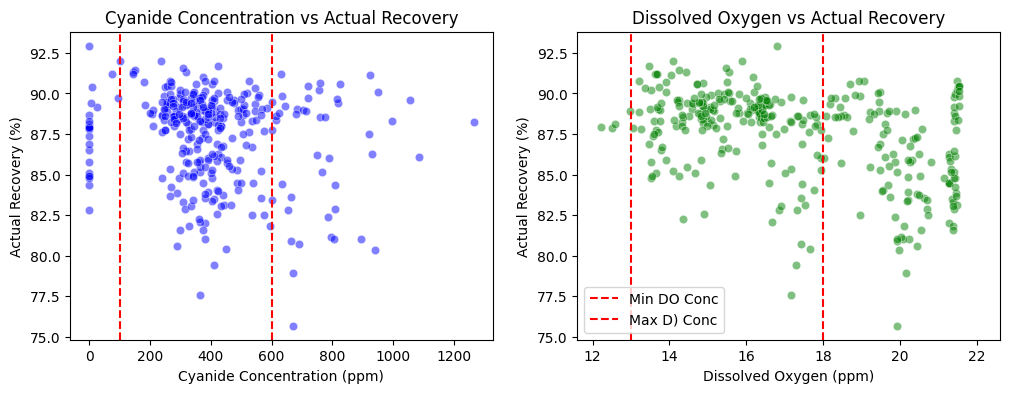

In [810]:
# Plot subplot distributions of CN Concentration and DO Concentration
plt.figure(figsize=(12, 4))

# Plot distribution of CN Concentration
plt.subplot(1, 2, 1)
sns.histplot(df['CN_Concentration'], bins=30, kde=True, color='blue')
plt.title("Distribution of Cyanide Concentration")
plt.xlabel("Cyanide Concentration (ppm)")
plt.ylabel("Frequency")
plt.axvline(min_cn_conc, color='red', linestyle='--', label='Min CN Conc')
plt.axvline(max_cn_conc, color='red', linestyle='--', label='Max CN Conc')

# Plot distribution of DO Concentration
plt.subplot(1, 2, 2)
sns.histplot(df['Dissolved_Oxygen'], bins=30, kde=True, color='green')
plt.title("Distribution of DO Concentration")
plt.xlabel("DO Concentration (ppm)")
# Set min/max axis limits
plt.xlim(df['Dissolved_Oxygen'].min() * 0.95, df['Dissolved_Oxygen'].max() * 1.05)
plt.ylabel("Frequency")
plt.axvline(min_do_conc, color='red', linestyle='--', label='Min CN Conc')
plt.axvline(max_do_conc, color='red', linestyle='--', label='Max CN Conc')
plt.show()

# Plot distribution of CN Concentration with Recoveries
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(x='CN_Concentration', y='Actual_Recovery', data=df, alpha=0.5, color='blue')
plt.axvline(min_cn_conc, color='red', linestyle='--', label='Min CN Conc')
plt.axvline(max_cn_conc, color='red', linestyle='--', label='Max CN Conc')
plt.title("Cyanide Concentration vs Actual Recovery")
plt.xlabel("Cyanide Concentration (ppm)")
plt.ylabel("Actual Recovery (%)")

plt.subplot(1, 2, 2)
sns.scatterplot(x='Dissolved_Oxygen', y='Actual_Recovery', data=df, alpha=0.5, color='green')
plt.axvline(min_do_conc, color='red', linestyle='--', label='Min DO Conc')
plt.axvline(max_do_conc, color='red', linestyle='--', label='Max D) Conc')
plt.title("Dissolved Oxygen vs Actual Recovery")
plt.xlabel("Dissolved Oxygen (ppm)")
plt.xlim(df['Dissolved_Oxygen'].min() * 0.95, df['Dissolved_Oxygen'].max() * 1.05)
plt.ylabel("Actual Recovery (%)")

plt.legend()
plt.show()

In [830]:
# --- Define grid parameters ---
cn_step = 5  	# ppm per step
do_step = 1  	# ppm per step

cn_vals = np.linspace(min_cn_conc, max_cn_conc, (int((max_cn_conc - min_cn_conc) / cn_step) + 1))
do_vals = np.linspace(min_do_conc, max_do_conc, (int((max_do_conc - min_do_conc) / do_step) + 1))

In [831]:
# --- Fixed parameter values ---
grade = 2.00              			# g/t
fines = 0.9                			# % of total grade
particle_size = 110        			# in µm

grade_x_fines = grade * fines       # g/t × %

# Generate full grid
cn_grid, do_grid = np.meshgrid(cn_vals, do_vals)
cn_flat = cn_grid.flatten()
do_flat = do_grid.flatten()

# Build input DataFrame for prediction
df_grid = pd.DataFrame({
    "Grade_x_Fines": grade_x_fines,
    "Particle_Size": particle_size,
    "Dissolved_Oxygen": do_flat,
    "CN_Concentration": cn_flat
})

# Predict recovery
df_grid["Predicted_Recovery"] = model.predict(df_grid)

# Sort CN and DO values for proper axis rendering
cn_sorted = np.sort(df_grid["CN_Concentration"].unique())
do_sorted = np.sort(df_grid["Dissolved_Oxygen"].unique())

# Reshape to matrix
heatmap_df = df_grid.pivot(index="CN_Concentration", columns="Dissolved_Oxygen", values="Predicted_Recovery")
heatmap_df = heatmap_df.reindex(index=cn_sorted, columns=do_sorted)  # enforce order

# Plot
fig = px.imshow(
    heatmap_df.values,
    x=do_sorted, y=cn_sorted,
    color_continuous_scale="YlOrRd",
    labels=dict(x="Dissolved Oxygen (ppm)", y="Cyanide (ppm)", color="Recovery (%)"),
    title=f"Predicted Recovery Heatmap<br>Grade x Fines = {grade_x_fines}, "
          f"Particle Size = {particle_size} µm",
    aspect="auto",
    width=800,
	height=600
)

fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()

In [829]:
# Fixed parameters (set to realistic values)
particle_size = 110        # µm
tonnes = 5000              # daily or per-batch processed tonnes

# Constants
CN_PENALTY_THRESHOLD = 450
CN_PENALTY_WEIGHT = 0.5  # USD per ppm above threshold

# Grid
cn_vals = np.linspace(min_cn_conc, max_cn_conc, 61)
do_vals = np.linspace(min_do_conc, max_do_conc, 61)
cn_grid, do_grid = np.meshgrid(cn_vals, do_vals)
cn_flat = cn_grid.flatten()
do_flat = do_grid.flatten()

# Predict recovery
df_grid = pd.DataFrame({
    "Grade_x_Fines": grade_x_fines,
    "Particle_Size": particle_size,
    "Dissolved_Oxygen": do_flat,
    "CN_Concentration": cn_flat
})
df_grid["Predicted_Recovery"] = model.predict(df_grid)

# Economic calculation
recovery = df_grid["Predicted_Recovery"]
revenue = recovery / 100 * grade * tonnes * GOLD_PRICE_USD_PER_G
cn_cost = cn_flat * NACN_PRICE_USD_PER_KG / 1000 * tonnes
do_cost = do_flat * DO_PRICE_USD_PER_PPM_T * tonnes
penalty = np.maximum(0, cn_flat - CN_PENALTY_THRESHOLD) * CN_PENALTY_WEIGHT * tonnes

df_grid["Net_Value"] = revenue - cn_cost - do_cost - penalty

# Pivot and sort
cn_sorted = np.sort(df_grid["CN_Concentration"].unique())
do_sorted = np.sort(df_grid["Dissolved_Oxygen"].unique())

heatmap_df = df_grid.pivot(index="CN_Concentration", columns="Dissolved_Oxygen", values="Net_Value")
heatmap_df = heatmap_df.reindex(index=cn_sorted, columns=do_sorted)

# Plot
fig = px.imshow(
    heatmap_df.values,
    x=do_sorted, y=cn_sorted,
    color_continuous_scale="YlOrRd",
    labels=dict(x="Dissolved Oxygen (ppm)", y="Cyanide (ppm)", color="Net Value (USD/t)"),
    title=f"Predicted Net Value Heatmap<br>Grade x Fines = {grade_x_fines}, "
    	  f"Au Grade = {grade} g/t, Tonnes = {tonnes}",
    aspect="auto",
    width=800,
	height=600
)

fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()


In [832]:
# --- Optimisation Function ---
def simulate_dosage_recommendation(row, model):
    grade = row["Grade_x_Fines"]
    size = row["Particle_Size"]
    tonnes = row["Tonnes_Processed"]
    au_grade = row["Au_Grade"]

    best_value = -np.inf
    best_combo = None
    result_grid = []

    for cn in cn_vals:
        for do in do_vals:
            X_sim = pd.DataFrame([{
                "Grade_x_Fines": grade,
                "Particle_Size": size,
                "Dissolved_Oxygen": do,
                "CN_Concentration": cn
            }])
            recovery = model.predict(X_sim)[0]

            revenue = recovery / 100 * au_grade * tonnes * GOLD_PRICE_USD_PER_G
            cn_cost = cn * NACN_PRICE_USD_PER_KG / 1000 * tonnes
            do_cost = do * DO_PRICE_USD_PER_PPM_T * tonnes
            cn_penalty = max(0, cn - penalty_threshold) * penalty_weight * tonnes

            net_value = revenue - cn_cost - do_cost - cn_penalty

            result_grid.append({
                "CN": cn,
                "DO": do,
                "Net_Value": net_value
            })

            if net_value > best_value:
                best_value = net_value
                best_combo = (cn, do)

    df_result = pd.DataFrame(result_grid)
    threshold = best_value * 0.90
    df_accept = df_result[df_result["Net_Value"] >= threshold]

    # Clamp recommended ranges
    cn_min = max(df_accept["CN"].min(), cn_lower_bound)
    cn_max = min(df_accept["CN"].max(), cn_upper_bound)
    do_min = max(df_accept["DO"].min(), do_lower_bound)
    do_max = min(df_accept["DO"].max(), do_upper_bound)

    return {
        "Recommended_CN": best_combo[0],
        "Recommended_DO": best_combo[1],
        "CN_Min": cn_min,
        "CN_Max": cn_max,
        "DO_Min": do_min,
        "DO_Max": do_max
    }

# --- Apply in Parallel using Swifter ---
recommendations = df.swifter.apply(simulate_dosage_recommendation, axis=1, model=model)

# --- Combine with Original DataFrame ---
recommendations_df = pd.DataFrame(recommendations.tolist())
df_with_recommendations = pd.concat([df.reset_index(drop=True), recommendations_df], axis=1)

# Save the DataFrame with recommendations
df_with_recommendations.to_csv("df_with_recommendations.csv", index=False)

# Preview
df_with_recommendations[['Date', 'Recommended_CN', 'Recommended_DO', 'CN_Min', 'CN_Max', 'DO_Min', 'DO_Max']].head().round(2)


Dask Apply:   0%|          | 0/17 [00:00<?, ?it/s]

,Date,Recommended_CN,Recommended_DO,CN_Min,CN_Max,DO_Min,DO_Max
0,2024-06-01,100.0,13.0,200,465.0,13.0,18.0
1,2024-06-02,100.0,15.0,200,465.0,13.0,18.0
2,2024-06-03,100.0,15.0,200,470.0,13.0,18.0
3,2024-06-04,100.0,13.0,200,470.0,13.0,18.0
4,2024-06-05,100.0,13.0,200,465.0,13.0,18.0


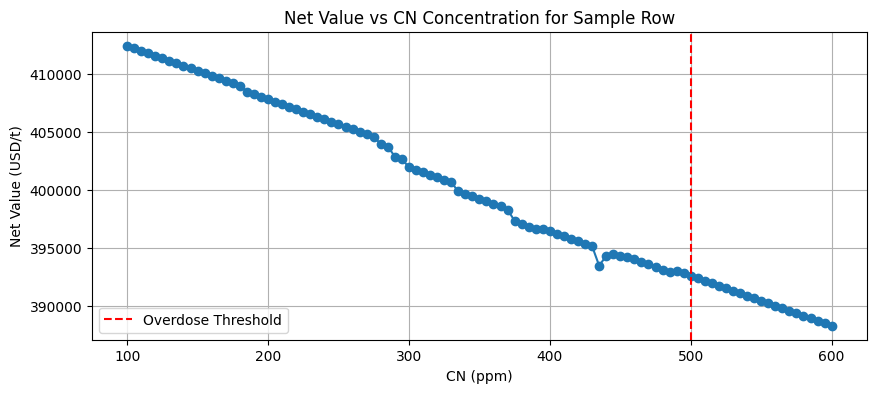

In [833]:
test_row = df.iloc[0]
net_values = []
for cn in cn_vals:
    row_values = []
    for do in do_vals:
        X_sim = pd.DataFrame([{
            "Grade_x_Fines": test_row["Grade_x_Fines"],
            "Particle_Size": test_row["Particle_Size"],
            "Dissolved_Oxygen": do,
            "CN_Concentration": cn
        }])
        recovery = model.predict(X_sim)[0]
        revenue = (
            recovery / 100 * test_row["Au_Grade"] * 
            test_row["Tonnes_Processed"] * GOLD_PRICE_USD_PER_G
		)
        cn_cost = cn * NACN_PRICE_USD_PER_KG / 1000 * test_row["Tonnes_Processed"]
        do_cost = do * DO_PRICE_USD_PER_PPM_T * test_row["Tonnes_Processed"]
        net = revenue - cn_cost - do_cost
        row_values.append(net)
    net_values.append(max(row_values))  # best DO for this CN

plt.figure(figsize=(10, 4))
plt.plot(cn_vals, net_values, marker='o')
plt.title("Net Value vs CN Concentration for Sample Row")
plt.xlabel("CN (ppm)")
plt.ylabel("Net Value (USD/t)")
plt.grid(True)
plt.axvline(cn_upper_bound, color='red', linestyle='--', label='Overdose Threshold')
plt.legend()
plt.show()


## Apply Dosage Simulation to Entire Dataset

In [835]:
# Apply dosage simulation to the full dataset (note: may take some time)
full_recommendations = df.apply(simulate_dosage_recommendation, axis=1, model=model)

# Combine results
full_recommendations_df = pd.DataFrame(full_recommendations.tolist())
df_with_recommendations = pd.concat([df.reset_index(drop=True), full_recommendations_df], axis=1)

# Save the dataframe with recommendations to CSV
df_with_recommendations.to_csv("df_with_recommendations.csv", index=False)

## Create CN & DO Band Recommendations

In [ ]:
# Function to simulate band recommendations using model
def calculate_optimal_band(row, model, cn_range, do_range):
	grade_fines = row["Grade_x_Fines"]
	psd = row["Particle_Size"]

	best_value = -np.inf
	best_cn, best_do, best_recovery = np.nan, np.nan, np.nan

	band_results = []
	for cn in cn_range:
		for do in do_range:
			X_sim = pd.DataFrame([{
				"Grade_x_Fines": grade_fines,
				"Particle_Size": psd,
				"Dissolved_Oxygen": do,
				"CN_Concentration": cn,
			}])
			recovery = model.predict(X_sim)[0]
			revenue = recovery / 100 * 31.1035 * GOLD_PRICE_USD_PER_G
			cost = cn / 1_000_000 * 17.0 * 1000 + do * 0.10
			net = revenue - cost
			band_results.append((cn, do, recovery, net))
			if net > best_value:
				best_value = net
				best_cn, best_do, best_recovery = cn, do, recovery

	df_band = pd.DataFrame(band_results, columns=["CN", "DO", "Recovery", "NetValue"])
	top_band = df_band[df_band["NetValue"] >= 0.98 * best_value]
	cn_low, cn_high = top_band["CN"].min(), top_band["CN"].max()
	do_low, do_high = top_band["DO"].min(), top_band["DO"].max()
	return pd.Series({
		"CN_Recommended_Low": cn_low,
		"CN_Recommended_High": cn_high,
		"DO_Recommended_Low": do_low,
		"DO_Recommended_High": do_high,
		"Optimal_CN": best_cn,
		"Optimal_DO": best_do,
		"Optimal_Recovery": best_recovery,
		"Optimal_Net_Value_USD_t": best_value,
	})

# Define simulation ranges
cn_range = np.linspace(cn_lower_bound, cn_upper_bound, 15)  # ppm
do_range = np.linspace(do_lower_bound, do_upper_bound, 15)     # ppm

# Apply row-wise simulation
recommendations = df.apply(lambda row: calculate_optimal_band(row, model, cn_range, do_range), axis=1)
df = pd.concat([df.reset_index(drop=True), recommendations.reset_index(drop=True)], axis=1)

df[["CN_Recommended_Low",
		"CN_Recommended_High",
		"DO_Recommended_Low",
		"DO_Recommended_High",
		"Optimal_CN",
		"Optimal_DO",
		"Optimal_Recovery",
		"Optimal_Net_Value_USD_t"]].head()

# Save the dataFrame with optimal recommendations to CSV
df.to_csv("df_with_optimal_recommendations.csv", index=False)

## Visualise Actual vs Recommended CN and DO over Time
Generate a dual-axis Plotly time series plot with:
* **Actual CN vs Recommended CN Range**
* **Actual DO vs Recommended DO Range**

Each with shaded bands and hover tooltips.

In [837]:
df.columns

Index(['Date', 'Au_Grade', 'Au_Feed_Grams', 'CN_Tailings_Concentration',
       'Au_Tailings_Grams', 'Leach_Feed_Gt_150um_Day',
       'Leach_Feed_Gt_75um_Day', 'Leach_Feed_Lt_75um_Day', 'CN_Concentration',
       'Tonnes_Processed', 'Dissolved_Oxygen', 'Fines_Fraction',
       'Grade_x_Fines', 'Particle_Size', 'Actual_Recovery',
       'Predicted_Recovery', 'Actual_Gold_Revenue', 'Alt_Gold_Revenue',
       'Actual_CN_Cost', 'Actual_DO_Cost', 'Actual_Net_Value_USD_t',
       'Kinetic_Recovery'],
      dtype='object')

In [836]:
# Define axis values
dates = df["Date"]
cn_actual = df["CN_Concentration"]
cn_low = df["CN_Recommended_Low"]
cn_high = df["CN_Recommended_High"]
do_actual = df["Dissolved_Oxygen"]
do_low = df["DO_Recommended_Low"]
do_high = df["DO_Recommended_High"]
net_value = df.get("Net_Value_USD_t", pd.Series([None] * len(df)))

# Create custom hover text
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Start with the required fields
hover_text = (
    "Date: " + df["Date"].dt.strftime("%Y-%m-%d") +
    "<br>CN Actual: " + cn_actual.round(1).astype(str) + " ppm" +
    "<br>CN Range: " + cn_low.round(1).astype(str) + " - " + cn_high.round(1).astype(str) +
    "<br>DO Actual: " + do_actual.round(1).astype(str) + " ppm" +
    "<br>DO Range: " + do_low.round(1).astype(str) + " - " + do_high.round(1).astype(str)
)

# Now append Net Value safely row-by-row (not as a string append)
if "Net_Value_USD_t" in df.columns:
    hover_text += "<br>Net Value: $" + df["Net_Value_USD_t"].round(2).astype(str)



# Build figure
fig = go.Figure()

# CN actual
fig.add_trace(go.Scatter(
	x=dates, y=cn_actual, mode="lines", name="CN Actual",
	line=dict(color="black"), hovertext=hover_text, hoverinfo="text"
))

# CN shaded band
fig.add_trace(go.Scatter(
	x=dates.tolist() + dates[::-1].tolist(),
	y=cn_high.tolist() + cn_low[::-1].tolist(),
	fill='toself',
	fillcolor='rgba(100,100,100,0.15)',
	line=dict(color='rgba(255,255,255,0)'),
	name='CN Recommended Range',
	hoverinfo="skip"
))

# DO actual
fig.add_trace(go.Scatter(
	x=dates, y=do_actual, mode="lines", name="DO Actual",
	line=dict(color="blue", dash="dot"), yaxis="y2",
	hovertext=hover_text, hoverinfo="text"
))

# DO shaded band
fig.add_trace(go.Scatter(
	x=dates.tolist() + dates[::-1].tolist(),
	y=do_high.tolist() + do_low[::-1].tolist(),
	fill='toself',
	fillcolor='rgba(135,206,250,0.25)',
	line=dict(color='rgba(255,255,255,0)'),
	name='DO Recommended Range',
	hoverinfo="skip",
	yaxis="y2"
))

# Optional threshold overlays (e.g., static overdose)
fig.add_hline(y=cn_upper_bound, line_dash="dot", line_color="red", annotation_text="CN Overdose Threshold", annotation_position="top left")
fig.add_hline(y=do_lower_bound, line_dash="dot", line_color="blue", annotation_text="Low DO Threshold", annotation_position="bottom left", yref="y2")

# Layout
fig.update_layout(
	title="Actual vs Recommended CN and DO Over Time",
	xaxis_title="Date",
	yaxis=dict(title="Cyanide (ppm)"),
	yaxis2=dict(title="Dissolved Oxygen (ppm)", overlaying="y", side="right"),
	legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
	margin=dict(t=80),
	height=550
)

fig.show()

KeyError: 'CN_Recommended_Low'

In [757]:
fig = go.Figure()

# CN Actual
fig.add_trace(go.Scatter(
	x=df["Date"], y=df["CN_Concentration"],
	mode="lines", name="CN Actual",
	line=dict(color="black"),
	hovertemplate="Date: %{x}<br>CN Actual: %{y:.1f} ppm"
))

# CN Range
fig.add_trace(go.Scatter(
	x=df["Date"].tolist() + df["Date"][::-1].tolist(),
	y=df["CN_Recommended_High"].tolist() + df["CN_Recommended_Low"][::-1].tolist(),
	fill="toself", fillcolor="rgba(100,100,100,0.2)",
	line=dict(color="rgba(255,255,255,0)"),
	hoverinfo="skip", name="CN Recommended Range"
))

# DO Actual
fig.add_trace(go.Scatter(
	x=df["Date"], y=df["Dissolved_Oxygen"],
	mode="lines", name="DO Actual",
	line=dict(color="blue", dash="dot"),
	yaxis="y2",
	hovertemplate="Date: %{x}<br>DO Actual: %{y:.2f} ppm"
))

# DO Range
fig.add_trace(go.Scatter(
	x=df["Date"].tolist() + df["Date"][::-1].tolist(),
	y=df["DO_Recommended_High"].tolist() + df["DO_Recommended_Low"][::-1].tolist(),
	fill="toself", fillcolor="rgba(135,206,250,0.3)",
	line=dict(color="rgba(255,255,255,0)"),
	hoverinfo="skip", name="DO Recommended Range",
	yaxis="y2"
))

# Layout
fig.update_layout(
	title="Actual vs Recommended CN and DO Over Time",
	xaxis=dict(title="Date"),
	yaxis=dict(title="Cyanide (ppm)"),
	yaxis2=dict(title="Dissolved Oxygen (ppm)", overlaying="y", side="right"),
	legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
	margin=dict(t=80)
)

fig.show()


In [758]:
# Create the base figure
fig = go.Figure()

# CN Actual trace
fig.add_trace(go.Scatter(
	x=df["Date"],
	y=df["CN_Concentration"],
	mode="lines",
	name="CN Actual",
	line=dict(color="black"),
	hovertemplate="Date: %{x}<br>CN Actual: %{y:.1f} ppm"
))

# CN recommended range (shaded area)
fig.add_trace(go.Scatter(
	x=df["Date"].tolist() + df["Date"][::-1].tolist(),
	y=df["CN_Recommended_High"].tolist() + df["CN_Recommended_Low"][::-1].tolist(),
	fill="toself",
	fillcolor="rgba(100,100,100,0.2)",
	line=dict(color="rgba(255,255,255,0)"),
	hoverinfo="skip",
	name="CN Recommended Range"
))

# DO Actual trace on secondary axis
fig.add_trace(go.Scatter(
	x=df["Date"],
	y=df["Dissolved_Oxygen"],
	mode="lines",
	name="DO Actual",
	line=dict(color="blue", dash="dot"),
	yaxis="y2",
	hovertemplate="Date: %{x}<br>DO Actual: %{y:.2f} ppm"
))

# DO recommended range (shaded area)
fig.add_trace(go.Scatter(
	x=df["Date"].tolist() + df["Date"][::-1].tolist(),
	y=df["DO_Recommended_High"].tolist() + df["DO_Recommended_Low"][::-1].tolist(),
	fill="toself",
	fillcolor="rgba(135,206,250,0.3)",
	line=dict(color="rgba(255,255,255,0)"),
	hoverinfo="skip",
	name="DO Recommended Range",
	yaxis="y2"
))

# Economic overlays
fig.add_trace(go.Scatter(
	x=df["Date"],
	y=df["Actual_Net_Value_USD_t"],
	mode="lines",
	name="Net Value (Actual)",
	line=dict(color="green", width=2, dash="dashdot"),
	yaxis="y3",
	hovertemplate="Date: %{x}<br>Net Value: $%{y:.2f}/t"
))

# Layout updates
fig.update_layout(
	title="CN and DO Actuals vs Recommendations with Economic Overlay",
	xaxis=dict(title="Date"),
	yaxis=dict(title="Cyanide (ppm)"),
	yaxis2=dict(title="Dissolved Oxygen (ppm)", overlaying="y", side="right"),
	yaxis3=dict(
		title="Net Value (USD/t)",
		anchor="free",
		overlaying="y",
		side="left",
		position=0.05,
		showgrid=False
	),
	legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
	margin=dict(t=80)
)

fig.show()

In [759]:
# Recalculate CN/DO bands from the correct column names
df["Recommended_CN_Low"] = df["Optimal_CN"] * 0.85
df["Recommended_CN_High"] = df["Optimal_CN"] * 1.15
df["Recommended_DO_Low"] = df["Optimal_DO"] * 0.90
df["Recommended_DO_High"] = df["Optimal_DO"] * 1.10

# Threshold margins
cn_margin = 50
do_margin = 1

# Add thresholds
df["CN_Overdose_Threshold"] = df["Recommended_CN_High"] + cn_margin
df["DO_Low_Threshold"] = df["Recommended_DO_Low"] - do_margin

# Net value delta
df["Net_Value_Delta"] = df["Optimal_Net_Value_USD_t"] - df["Actual_Net_Value_USD_t"]

# Custom hover text
hover_text = (
	"Date: " + df["Date"].astype(str) +
	"<br>CN Actual: " + df["CN_Concentration"].round(1).astype(str) + " ppm" +
	"<br>CN Range: " + df["Recommended_CN_Low"].round(1).astype(str) + " - " + df["Recommended_CN_High"].round(1).astype(str) +
	"<br>DO Actual: " + df["Dissolved_Oxygen"].round(1).astype(str) + " ppm" +
	"<br>DO Range: " + df["Recommended_DO_Low"].round(1).astype(str) + " - " + df["Recommended_DO_High"].round(1).astype(str) +
	"<br>Net Value Δ: $" + df["Net_Value_Delta"].round(2).astype(str)
)

# Create updated plot
fig = go.Figure()

# CN actual
fig.add_trace(go.Scatter(x=df["Date"], y=df["CN_Concentration"], mode='lines',
						 name='CN Actual', line=dict(color='black'), hovertext=hover_text, hoverinfo='text'))

# CN range
fig.add_trace(go.Scatter(x=pd.concat([df["Date"], df["Date"][::-1]]),
						 y=pd.concat([df["Recommended_CN_High"], df["Recommended_CN_Low"][::-1]]),
						 fill='toself', fillcolor='rgba(100,100,100,0.2)',
						 line=dict(color='rgba(255,255,255,0)'), name='CN Recommended Range'))

# DO actual
fig.add_trace(go.Scatter(x=df["Date"], y=df["Dissolved_Oxygen"], mode='lines',
						 name='DO Actual', line=dict(color='blue', dash='dot'), yaxis='y2'))

# DO range
fig.add_trace(go.Scatter(x=pd.concat([df["Date"], df["Date"][::-1]]),
						 y=pd.concat([df["Recommended_DO_High"], df["Recommended_DO_Low"][::-1]]),
						 fill='toself', fillcolor='rgba(135,206,250,0.3)',
						 line=dict(color='rgba(255,255,255,0)'), name='DO Recommended Range',
						 yaxis='y2'))

# Threshold lines
fig.add_trace(go.Scatter(x=df["Date"], y=df["CN_Overdose_Threshold"],
						 mode='lines', name='CN Overdose Threshold',
						 line=dict(color='red', dash='dot')))
fig.add_trace(go.Scatter(x=df["Date"], y=df["DO_Low_Threshold"],
						 mode='lines', name='Low DO Threshold',
						 line=dict(color='red', dash='dash'), yaxis='y2'))

# Layout with updated style
fig.update_layout(
	title='CN and DO Actuals vs Recommendations with Economic Overlay',
	plot_bgcolor='white',
	paper_bgcolor='white',
	xaxis=dict(title='Date'),
	yaxis=dict(title='Cyanide (ppm)', showgrid=True, gridcolor='lightgrey'),
	yaxis2=dict(title='Dissolved Oxygen (ppm)', overlaying='y', side='right', showgrid=False),
	legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0)
)

fig.show()


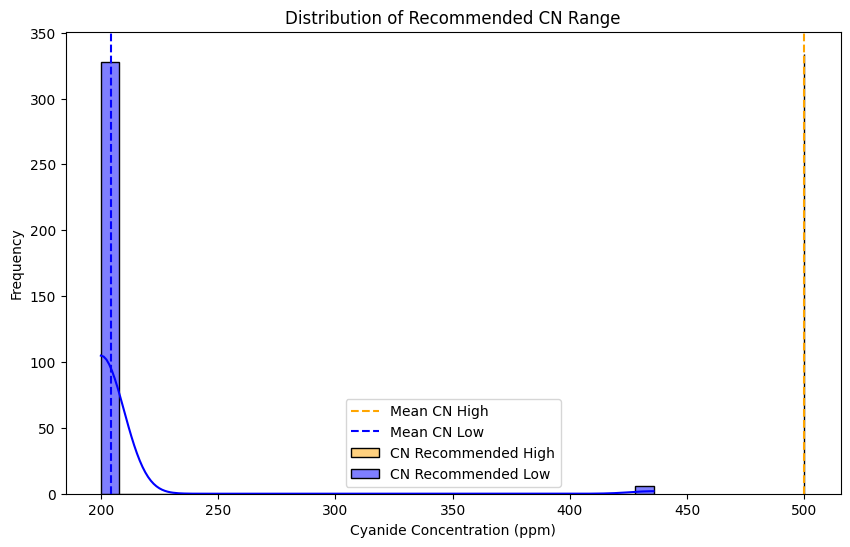

In [760]:
# df['CN_Recommended_High'].describe()
# df['CN_Recommended_Low'].describe()

# Plot histogram of recommended CN range
plt.figure(figsize=(10, 6))
sns.histplot(df['CN_Recommended_High'], bins=30, kde=True, color='orange', label='CN Recommended High')
sns.histplot(df['CN_Recommended_Low'], bins=30, kde=True, color='blue', label='CN Recommended Low')
plt.axvline(df['CN_Recommended_High'].mean(), color='orange', linestyle='--', label='Mean CN High')
plt.axvline(df['CN_Recommended_Low'].mean(), color='blue', linestyle='--', label='Mean CN Low')
plt.title('Distribution of Recommended CN Range')
plt.xlabel('Cyanide Concentration (ppm)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(False)
plt.show()

In [761]:
# Define window
start_date = pd.to_datetime("2024-09-15")
window_days = 14
end_date = start_date + timedelta(days=window_days)

# Filter
df_window = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()

# Extract relevant fields
cn_actual = df_window["CN_Concentration"]
do_actual = df_window["Dissolved_Oxygen"]
cn_low = df_window["CN_Recommended_Low"]
cn_high = df_window["CN_Recommended_High"]
do_low = df_window["DO_Recommended_Low"]
do_high = df_window["DO_Recommended_High"]
net_value = df_window["Actual_Net_Value_USD_t"]
value_delta = df_window["Optimal_Net_Value_USD_t"] - net_value
dates = df_window["Date"]

# Tooltip
hover_text = (
	"Date: " + df_window["Date"].dt.strftime("%Y-%m-%d") +
	"<br>CN Actual: " + cn_actual.round(1).astype(str) + " ppm" +
	"<br>CN Range: " + cn_low.round(1).astype(str) + " - " + cn_high.round(1).astype(str) +
	"<br>DO Actual: " + do_actual.round(1).astype(str) + " ppm" +
	"<br>DO Range: " + do_low.round(1).astype(str) + " - " + do_high.round(1).astype(str) +
	"<br>Net Value Δ: $" + value_delta.round(2).astype(str)
)

# Plot
fig = go.Figure()

# CN actual
fig.add_trace(go.Scatter(
	x=dates, y=cn_actual, name="CN Actual",
	mode="lines", line=dict(color="black"),
	hovertext=hover_text, hoverinfo="text", yaxis="y"
))

# CN band
fig.add_trace(go.Scatter(
	x=dates.tolist() + dates[::-1].tolist(),
	y=cn_high.tolist() + cn_low[::-1].tolist(),
	fill="toself", fillcolor="rgba(100,100,100,0.15)",
	line=dict(color="rgba(255,255,255,0)"),
	name="CN Recommended Range", yaxis="y", showlegend=True
))

# DO actual
fig.add_trace(go.Scatter(
	x=dates, y=do_actual, name="DO Actual",
	mode="lines", line=dict(color="blue", dash="dot"),
	hoverinfo="skip", yaxis="y2"
))

# # DO band
# fig.add_trace(go.Scatter(
#     x=dates.tolist() + dates[::-1].tolist(),
#     y=do_high.tolist() + do_low[::-1].tolist(),
#     fill="toself", fillcolor="rgba(135,206,250,0.2)",
#     line=dict(color="rgba(255,255,255,0)"),
#     name="DO Recommended Range", yaxis="y2", showlegend=True
# ))

# Thresholds
fig.add_hline(y=cn_upper_bound, line=dict(color="red", width=1, dash="dash"),
			  annotation_text="CN Overdose Threshold", annotation_position="top left")
fig.add_hline(y=9.0, line=dict(color="blue", width=1, dash="dot"),
			  annotation_text="Low DO Threshold", annotation_position="top right", yref="y2")

# Layout with updated style
fig.update_layout(
	title='CN and DO Actuals vs Recommendations (Weekly Window)',
	plot_bgcolor='white',
	paper_bgcolor='white',
	template='plotly_white',
	xaxis=dict(title='Date'),
	yaxis=dict(title='Cyanide (ppm)', showgrid=False, gridcolor='lightgrey'),
	yaxis2=dict(title='Dissolved Oxygen (ppm)', overlaying='y', side='right', showgrid=False),
	legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0)
)

fig.show()

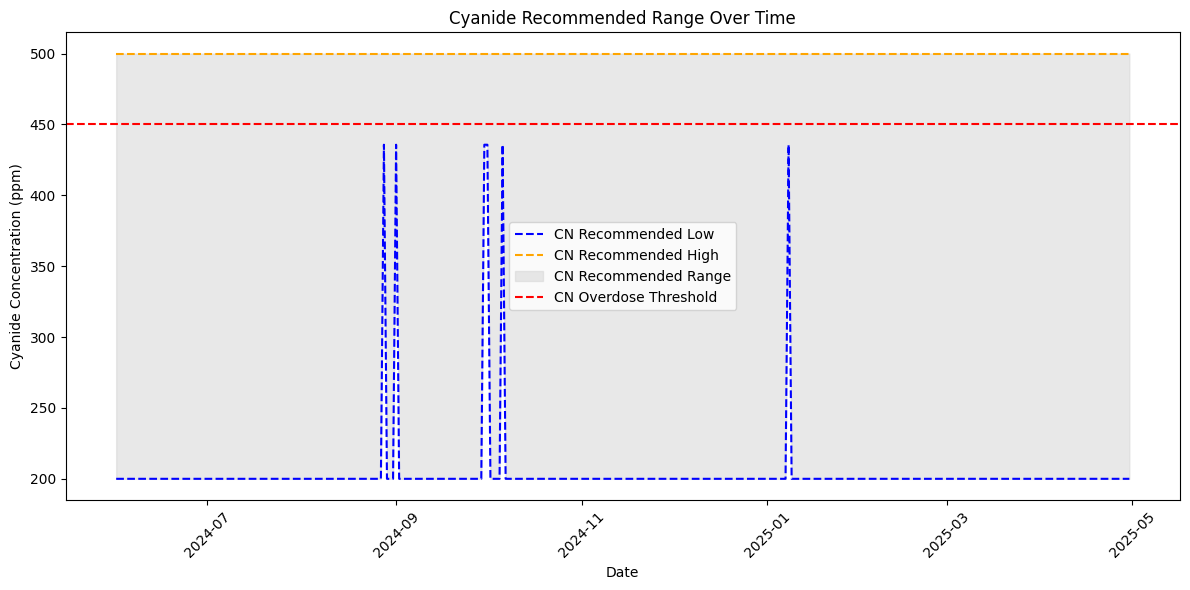

In [762]:
# Plot CN Recommended Range over time
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["CN_Recommended_Low"], label="CN Recommended Low", color="blue", linestyle="--")
plt.plot(df["Date"], df["CN_Recommended_High"], label="CN Recommended High", color="orange", linestyle="--")
plt.fill_between(df["Date"], df["CN_Recommended_Low"], df["CN_Recommended_High"],
				 color="lightgray", alpha=0.5, label="CN Recommended Range")	
plt.axhline(y=450, color='red', linestyle='--', label="CN Overdose Threshold")
plt.title("Cyanide Recommended Range Over Time")
plt.xlabel("Date")
plt.ylabel("Cyanide Concentration (ppm)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [679]:
test_row = df.iloc[0]
net_values = []
for cn in cn_vals:
    row_values = []
    for do in do_vals:
        X_sim = pd.DataFrame([{
            "Grade_x_Fines": test_row["Grade_x_Fines"],
            "Particle_Size": test_row["Particle_Size"],
            "Dissolved_Oxygen": do,
            "CN_Concentration": cn
        }])
        recovery = model.predict(X_sim)[0]
        revenue = recovery / 100 * test_row["Au_Grade"] * test_row["Tonnes_Processed"] * GOLD_PRICE_USD_PER_G
        cn_cost = cn * NACN_PRICE_USD_PER_KG / 1000 * test_row["Tonnes_Processed"]
        do_cost = do * DO_PRICE_USD_PER_PPM_T * test_row["Tonnes_Processed"]
        net = revenue - cn_cost - do_cost
        row_values.append(net)
    net_values.append(max(row_values))  # best DO for this CN

plt.figure(figsize=(10, 4))
plt.plot(cn_vals, net_values, marker='o')
plt.title("Net Value vs CN Concentration for Sample Row")
plt.xlabel("CN (ppm)")
plt.ylabel("Net Value (USD/t)")
plt.grid(True)
plt.axvline(450, color='red', linestyle='--', label='Overdose Threshold')
plt.legend()
plt.show()


KeyError: 'Grade_x_Fines'

In [671]:
# Define window
start_date = pd.to_datetime("2025-03-15")
window_days = 7
end_date = start_date + timedelta(days=window_days)

# Filter
df_plot = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()

# Create subplots: 2 rows, shared x-axis
fig = make_subplots(
	rows=2, cols=1,
	shared_xaxes=True,
	vertical_spacing=0.15,
	subplot_titles=("CN Actuals vs Recommended Range", "DO Actuals vs Recommended Range")
)

# --- Subplot 1: CN ---
fig.add_trace(go.Scatter(
	x=df_plot["Date"], y=df_plot["CN_Concentration"],
	mode="lines+markers", name="CN Actual", line=dict(color="black")
), row=1, col=1)

fig.add_trace(go.Scatter(
	x=df_plot["Date"], y=df_plot["CN_Recommended_High"],
	mode="lines", line=dict(width=0), showlegend=False
), row=1, col=1)

fig.add_trace(go.Scatter(
	x=df_plot["Date"], y=df_plot["CN_Recommended_Low"],
	mode="lines", fill='tonexty', name="CN Recommended Range",
	line=dict(width=0), fillcolor="rgba(255,0,0,0.2)"
), row=1, col=1)

fig.add_trace(go.Scatter(
	x=df_plot["Date"], y=df_plot["CN_Overdose_Threshold"],
	mode="lines", name="CN Overdose Threshold",
	line=dict(color="red", dash="dash")
), row=1, col=1)

# --- Subplot 2: DO ---
fig.add_trace(go.Scatter(
	x=df_plot["Date"], y=df_plot["Optimal_DO"],
	mode="lines+markers", name="DO Actual", line=dict(color="blue", dash="dot")
), row=2, col=1)

fig.add_trace(go.Scatter(
	x=df_plot["Date"], y=df_plot["DO_Recommended_High"],
	mode="lines", line=dict(width=0), showlegend=False
), row=2, col=1)

fig.add_trace(go.Scatter(
	x=df_plot["Date"], y=df_plot["DO_Recommended_Low"],
	mode="lines", fill='tonexty', name="DO Recommended Range",
	line=dict(width=0), fillcolor="rgba(0,0,255,0.2)"
), row=2, col=1)

fig.add_trace(go.Scatter(
	x=df_plot["Date"], y=df_plot["DO_Low_Threshold"],
	mode="lines", name="Low DO Threshold",
	line=dict(color="navy", dash="dash")
), row=2, col=1)

# Layout tweaks
fig.update_layout(
	height=700,
	title="CN and DO Actuals vs Recommended Ranges (Subplot View)",
	legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
	margin=dict(t=80, b=40),
	xaxis_title="Date",
)

fig.update_yaxes(title_text="CN Concentration (ppm)", row=1, col=1)
fig.update_yaxes(title_text="DO Concentration (ppm)", row=2, col=1)

fig.show()


## Compare Model Predictions vs Actual Recovery
Generate side-by-side scatter or line plots for:
* Actual Recovery
* Predicted Recovery (XGBoost)
* Predicted Recovery (Kinetic)

Observe alignment and any systematic errors.

## Evaluate Deviation Statistics and Highlight Outliers
Calculate:
* CN Overdose or Underdose status (outside recommended range)
* DO deviation
* Recovery gap (Actual - Predicted)
* Economic impact (if CN cost / gold revenue is included)

Flag rows where:
* Actual CN > CN_Max or < CN_Min
* Actual Recovery significantly lower than either model

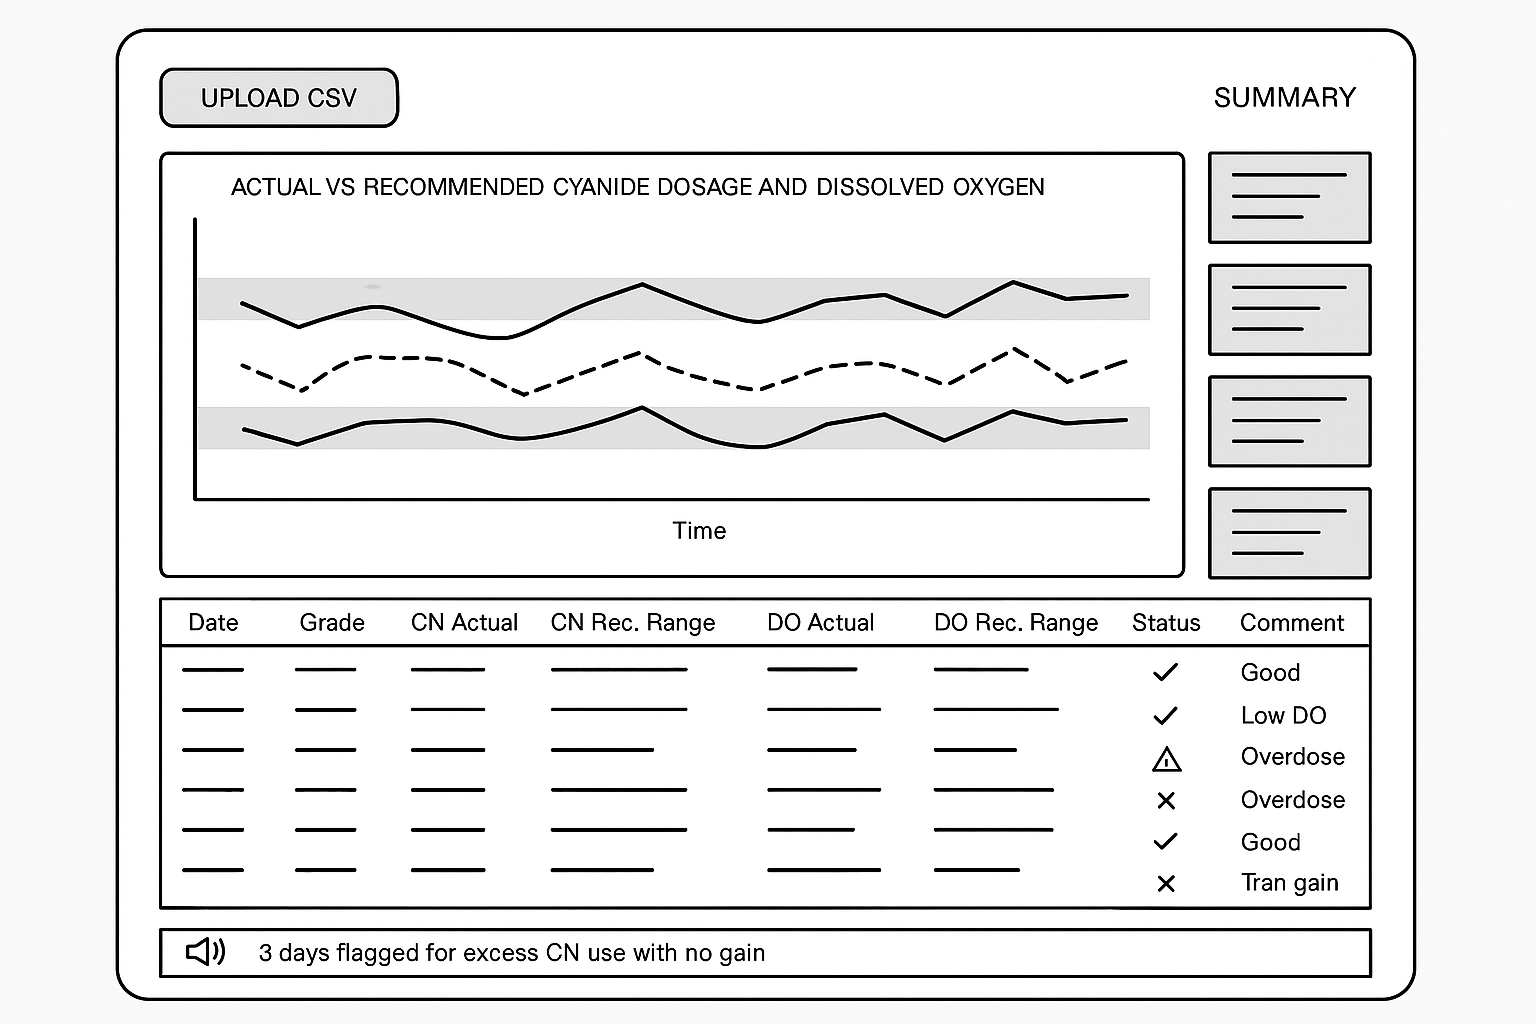

**🧠 Conceptual Approach: Multi-Parameter Band Definition**
We treat this as a 2D optimisation space:
* X-axis: Cyanide Dosage (ppm)
* Y-axis: Dissolved Oxygen (ppm)

Then, for each sample (or class of samples: similar grade × size profile), we simulate or model a surface of predicted recovery across combinations of CN and DO.

From this surface, we can:
* Find the peak recovery zone.
* Define iso-recovery contours (e.g. 98%, 95%, 90% of max recovery).

**Classify zones:**
* ✅ Optimal band: Recovery ≥ 98% of max, economically efficient.
* ⚠️ Acceptable band: 90–98%, but maybe higher cost or risk.
* ❌ Suboptimal: <90%, or excessive reagent cost.

**📊 Visual Display Options**
* 2D Contour Plot (for a single sample or average week)
* Contours show recovery
* Overlay shaded regions for optimal/acceptable/suboptimal
* Actual site point shown as a marker (with tooltip)
* Stacked Weekly Summary (Bar + Table)

For each day:
* Icon: ✅⚠️❌ depending on classification
* Bars for CN & DO vs recommended ranges
* Recovery achieved vs target
* Tooltip shows costs and losses
* Interactive Panel
* Dropdown to select week or day
* Plot on left, detailed metrics or comments on right

**🧮 Practical Implementation**
To generate the 2D bands:
* Use a grid search or 2D simulation over CN × DO space.
* Keep other variables (grade, size) fixed or average for the period.
* Evaluate predicted recovery and cost per combination.

Then:
* Extract contours and define thresholds
* Store the “optimal band” (region) as polygon bounds (for plotting)
* Classify actual data point location w.r.t these bounds

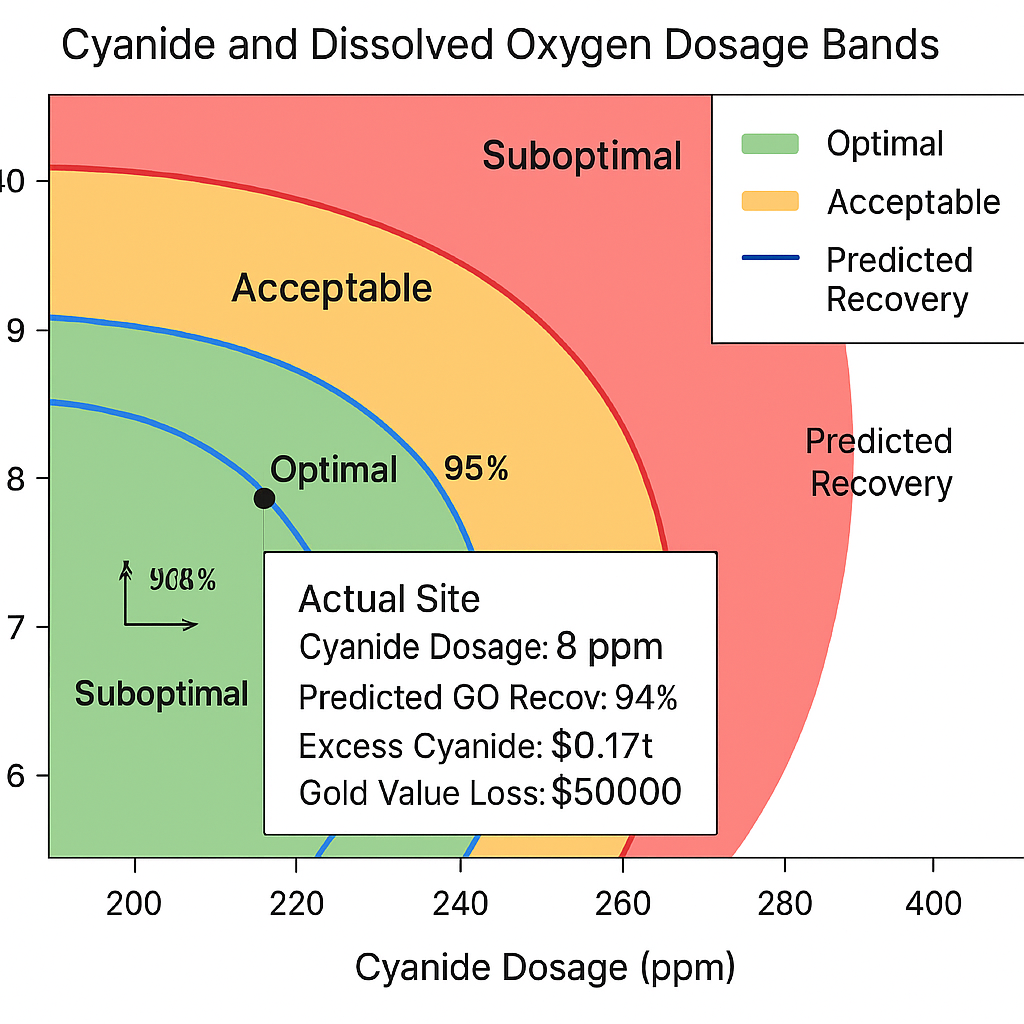

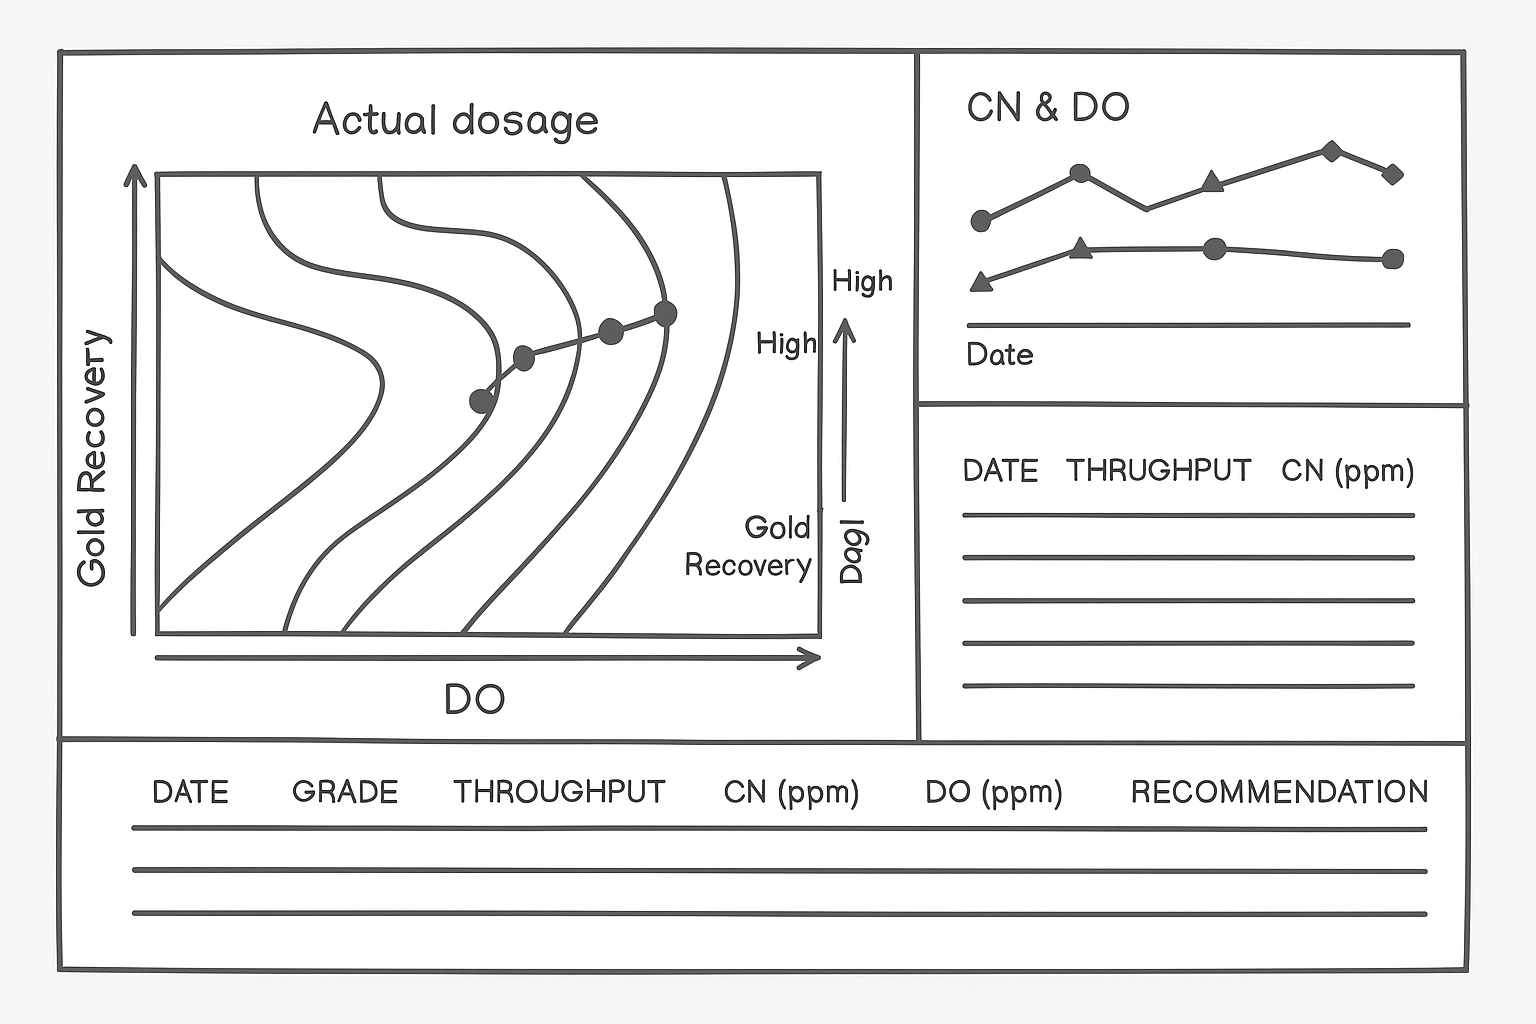

Daily Strip Panel – One column per day, showing colour-coded strips or mini-graphs for:
* Cyanide dosage vs range
* Dissolved oxygen vs range
* Recovery vs max
* Tooltip or value display on hover

In [672]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Define sample data since it was missing from the previous context
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
cn_dosage = [320, 350, 400, 470, 280, 500, 310]       # ppm
do_levels = [10, 9.5, 11, 7, 13, 6.5, 12]             # ppm
recovery = [96, 94, 92, 88, 85, 89, 93]               # %

# Create subplots
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.1,
					subplot_titles=("Cyanide Dosage (ppm)", "Dissolved Oxygen (ppm)", "Gold Recovery (%)"))

# CN Dosage plot
fig.add_trace(go.Bar(
	x=days,
	y=cn_dosage,
	marker_color=['green' if 300 <= val <= 450 else 'red' for val in cn_dosage],
	text=[f"{val} ppm" for val in cn_dosage],
	hoverinfo='text',
	name="CN Dosage"
), row=1, col=1)

# DO plot
fig.add_trace(go.Bar(
	x=days,
	y=do_levels,
	marker_color=['green' if 8 <= val <= 12 else 'red' for val in do_levels],
	text=[f"{val} ppm" for val in do_levels],
	hoverinfo='text',
	name="DO Level"
), row=2, col=1)

# Gold Recovery plot
fig.add_trace(go.Bar(
	x=days,
	y=recovery,
	marker_color=[
		'green' if val >= 95 else 'orange' if val >= 90 else 'red' for val in recovery
	],
	text=[f"{val}%" for val in recovery],
	hoverinfo='text',
	name="Recovery"
), row=3, col=1)

# Update layout
fig.update_layout(
	height=800,
	title_text="Weekly Performance Overview with Tooltips",
	showlegend=False
)

fig.show()


In [673]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import random
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Simulate data for one week
np.random.seed(1)
dates = pd.date_range(start="2024-06-01", periods=7, freq='D')
grades = np.round(np.random.uniform(1.5, 2.5, 7), 3)
cn_actual = np.round(np.random.uniform(250, 600, 7), 1)
cn_rec_min = np.full(7, 300)
cn_rec_max = np.full(7, 450)
do_actual = np.round(np.random.uniform(6, 13, 7), 1)
do_rec_min = np.full(7, 8)
do_rec_max = np.full(7, 12)

# Calculate status and comment
status = []
comment = []
for cn, do in zip(cn_actual, do_actual):
	if cn > 450:
		status.append("⚠️")
		comment.append("Overdose")
	elif do < 8:
		status.append("✔️")
		comment.append("Low DO")
	elif cn < 300:
		status.append("✖️")
		comment.append("Tran gain")
	else:
		status.append("✔️")
		comment.append("Good")

# Create dataframe
df = pd.DataFrame({
	"Date": dates.strftime('%Y-%m-%d'),
	"Grade": grades,
	"CN Actual": cn_actual,
	"CN Rec. Min": cn_rec_min,
	"CN Rec. Max": cn_rec_max,
	"DO Actual": do_actual,
	"DO Rec. Min": do_rec_min,
	"DO Rec. Max": do_rec_max,
	"Status": status,
	"Comment": comment
})

# Display the dataframe visually
df


,Date,Grade,CN Actual,CN Rec. Min,CN Rec. Max,DO Actual,DO Rec. Min,DO Rec. Max,Status,Comment
0,2024-06-01,1.917,370.9,300,450,6.2,8,12,✔️,Low DO
1,2024-06-02,2.220,388.9,300,450,10.7,8,12,✔️,Good
2,2024-06-03,1.500,438.6,300,450,8.9,8,12,✔️,Good
3,2024-06-04,1.802,396.7,300,450,9.9,8,12,✔️,Good
4,2024-06-05,1.647,489.8,300,450,7.0,8,12,⚠️,Overdose
5,2024-06-06,1.592,321.6,300,450,7.4,8,12,✔️,Low DO
6,2024-06-07,1.686,557.3,300,450,11.6,8,12,⚠️,Overdose


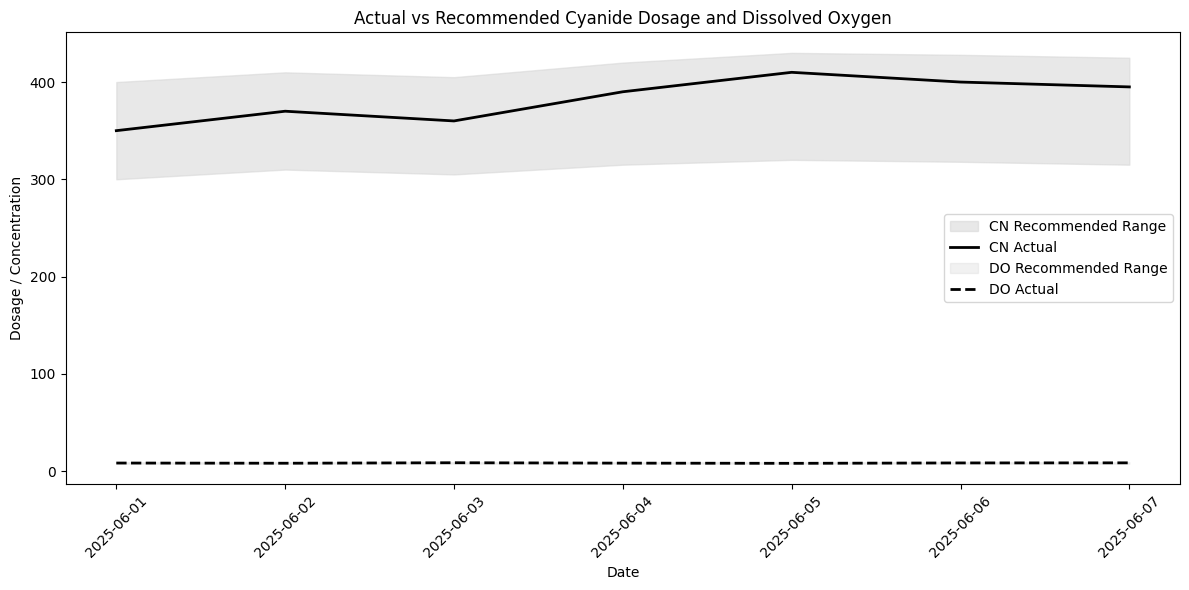

In [674]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data for the mockup chart
data = {
	'Date': pd.date_range(start='2025-06-01', periods=7, freq='D'),
	'CN_Actual': [350, 370, 360, 390, 410, 400, 395],
	'CN_Lower': [300, 310, 305, 315, 320, 318, 315],
	'CN_Upper': [400, 410, 405, 420, 430, 428, 425],
	'DO_Actual': [8.2, 8.0, 8.5, 8.1, 7.9, 8.3, 8.4],
	'DO_Lower': [7.5, 7.5, 7.6, 7.6, 7.5, 7.6, 7.5],
	'DO_Upper': [9.0, 9.0, 9.1, 9.0, 9.0, 9.1, 9.0]
}
df = pd.DataFrame(data)

# Plot setup
fig, ax = plt.subplots(figsize=(12, 6))

# CN dosage band and actual line
ax.fill_between(df['Date'], df['CN_Lower'], df['CN_Upper'], color='lightgray', alpha=0.5, label='CN Recommended Range')
ax.plot(df['Date'], df['CN_Actual'], color='black', label='CN Actual', linewidth=2)

# DO dosage band and actual line (dashed)
ax.fill_between(df['Date'], df['DO_Lower'], df['DO_Upper'], color='lightgray', alpha=0.3, label='DO Recommended Range')
ax.plot(df['Date'], df['DO_Actual'], color='black', linestyle='--', label='DO Actual', linewidth=2)

# Styling
ax.set_title("Actual vs Recommended Cyanide Dosage and Dissolved Oxygen")
ax.set_xlabel("Date")
ax.set_ylabel("Dosage / Concentration")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [675]:
import plotly.graph_objects as go

# Example logic for CN and DO recommendation bands (you can refine these)
df["CN_Rec_Low"] = df["CN_Actual"] * 0.8
df["CN_Rec_High"] = df["CN_Actual"] * 1.2
df["DO_Rec_Low"] = df["DO_Actual"] * 0.8
df["DO_Rec_High"] = df["DO_Actual"] * 1.2


import plotly.graph_objects as go

fig = go.Figure()

# CN traces
fig.add_trace(go.Scatter(
	x=df["Date"],
	y=df["CN_Actual"],
	name="CN Actual",
	mode="lines+markers",
	line=dict(color="black"),
	legendgroup="CN",
	legendgrouptitle_text="Cyanide",
	legendrank=1
))

fig.add_trace(go.Scatter(
	x=pd.concat([df["Date"], df["Date"][::-1]]),
	y=pd.concat([df["CN_Rec_High"], df["CN_Rec_Low"][::-1]]),
	fill='toself',
	fillcolor='rgba(0,0,0,0.1)',
	line=dict(color='rgba(0,0,0,0)'),
	hoverinfo='skip',
	name="CN Recommended Range",
	legendgroup="CN",
	showlegend=True,
	legendrank=2
))

# DO traces (secondary y-axis)
fig.add_trace(go.Scatter(
	x=df["Date"],
	y=df["DO_Actual"],
	name="DO Actual",
	mode="lines+markers",
	line=dict(color="black", dash='dash'),
	yaxis='y2',
	legendgroup="DO",
	legendgrouptitle_text="Dissolved Oxygen",
	legendrank=3
))

fig.add_trace(go.Scatter(
	x=pd.concat([df["Date"], df["Date"][::-1]]),
	y=pd.concat([df["DO_Rec_High"], df["DO_Rec_Low"][::-1]]),
	fill='toself',
	fillcolor='rgba(0,0,255,0.1)',
	line=dict(color='rgba(0,0,0,0)'),
	hoverinfo='skip',
	name="DO Recommended Range",
	yaxis='y2',
	legendgroup="DO",
	showlegend=True,
	legendrank=4
))

# Layout
fig.update_layout(
	title="Actual vs Recommended Cyanide and Dissolved Oxygen Dosage",
	xaxis_title="Date",
	yaxis=dict(title="Cyanide (ppm)"),
	yaxis2=dict(
		title="Dissolved Oxygen (ppm)",
		overlaying='y',
		side='right'
	),
	legend=dict(
		x=0, y=1, xanchor='left', yanchor='top',
		tracegroupgap=50,
		bgcolor='rgba(255,255,255,0.8)'
	),
	margin=dict(l=40, r=40, t=60, b=40)
)

fig.show()



In [676]:
import plotly.graph_objects as go
import pandas as pd
from datetime import datetime, timedelta

# Simulate 7 days of data
dates = [datetime(2025, 6, 1) + timedelta(days=i) for i in range(7)]
cn_actual = [350, 370, 360, 385, 410, 395, 390]
cn_low = [320, 340, 330, 355, 380, 365, 360]
cn_high = [420, 440, 430, 455, 480, 465, 460]
do_actual = [7.0, 7.5, 7.2, 8.0, 7.8, 8.1, 7.9]
do_low = [6.5, 6.8, 6.7, 7.2, 7.0, 7.3, 7.1]
do_high = [8.5, 8.8, 8.7, 9.2, 9.0, 9.3, 9.1]

fig = go.Figure()

# Cyanide traces
fig.add_trace(go.Scatter(x=dates, y=cn_actual, mode='lines+markers', name='CN Actual',
						 line=dict(color='black'), showlegend=False))
fig.add_trace(go.Scatter(x=dates + dates[::-1],
						 y=cn_high + cn_low[::-1],
						 fill='toself',
						 fillcolor='rgba(100,100,100,0.2)',
						 line=dict(color='rgba(255,255,255,0)'),
						 hoverinfo="skip",
						 name='CN Recommended Range',
						 showlegend=False))

# DO traces (secondary y-axis)
fig.add_trace(go.Scatter(x=dates, y=do_actual, mode='lines+markers', name='DO Actual',
						 line=dict(color='blue', dash='dot'), yaxis='y2', showlegend=False))
fig.add_trace(go.Scatter(x=dates + dates[::-1],
						 y=do_high + do_low[::-1],
						 fill='toself',
						 fillcolor='rgba(135,206,250,0.3)',
						 line=dict(color='rgba(255,255,255,0)'),
						 hoverinfo="skip",
						 name='DO Recommended Range',
						 yaxis='y2',
						 showlegend=False))

# Layout with simulated split legends as annotations
fig.update_layout(
	title='Actual vs Recommended Cyanide and Dissolved Oxygen Dosage',
	xaxis=dict(title='Date'),
	yaxis=dict(title='Cyanide (ppm)'),
	yaxis2=dict(title='Dissolved Oxygen (ppm)', overlaying='y', side='right'),
	annotations=[
		dict(x=0.01, y=1.07, xref='paper', yref='paper', text='⬤ CN Actual<br>▮ CN Recommended Range',
			 showarrow=False, align='left'),
		dict(x=0.99, y=1.07, xref='paper', yref='paper', text='⬤ DO Actual<br>▮ DO Recommended Range',
			 showarrow=False, align='right')
	],
	margin=dict(t=80)
)

fig.show()


In [677]:
# Example kinetic model function (placeholder - replace with real one)
def predict_recovery(cn_ppm, do_ppm, grade):
	"""
	Placeholder recovery model:
	- Recovery increases with CN and DO but saturates
	- Grade positively influences recovery
	"""
	cn_term = 1 - np.exp(-0.002 * cn_ppm)
	do_term = 1 - np.exp(-0.3 * do_ppm)
	recovery = grade * cn_term * do_term * 50  # Simplified model
	return np.clip(recovery, 0, 100)



# Simulated dataset for 7 days
dates = pd.date_range(start="2025-06-01", periods=7, freq='D')
grades = np.random.uniform(1.0, 3.0, size=7)  # Gold grade g/t

# Create result container
results = []

# Economic optimizer loop
for date, grade in zip(dates, grades):
	best_value = -np.inf
	optimal_cn = None
	optimal_do = None
	optimal_recovery = None
	optimal_cost = None
	optimal_revenue = None

	for cn in np.linspace(100, 700, 25):  # ppm
		for do in np.linspace(6, 10, 20):  # ppm
			recovery = predict_recovery(cn, do, grade)
			gold_value = recovery / 100 * 31.1035 * GOLD_PRICE_USD_PER_G  # USD/t
			cn_cost = cn / 1_000_000 * 1_000 * NACN_PRICE_USD_PER_KG  # USD/t
			net_value = gold_value - cn_cost

			if net_value > best_value:
				best_value = net_value
				optimal_cn = cn
				optimal_do = do
				optimal_recovery = recovery
				optimal_cost = cn_cost
				optimal_revenue = gold_value

	results.append({
		"Date": date,
		"Grade_gpt": grade,
		"Optimal_CN_ppm": round(optimal_cn, 1),
		"Optimal_DO_ppm": round(optimal_do, 2),
		"Predicted_Recovery_pct": round(optimal_recovery, 2),
		"Gold_Revenue_USD_t": round(optimal_revenue, 2),
		"CN_Cost_USD_t": round(optimal_cost, 2),
		"Net_Value_USD_t": round(best_value, 2)
	})

# Convert to DataFrame for review
df_optimised = pd.DataFrame(results)

df_optimised


,Date,Grade_gpt,Optimal_CN_ppm,Optimal_DO_ppm,Predicted_Recovery_pct,Gold_Revenue_USD_t,CN_Cost_USD_t,Net_Value_USD_t
0,2025-06-01,2.936523,650.0,9.37,100.00,2775.68,11.05,2764.63
1,2025-06-02,1.626848,700.0,10.00,58.23,1616.35,11.90,1604.45
2,2025-06-03,2.384645,700.0,10.00,85.36,2369.25,11.90,2357.35
3,2025-06-04,2.752778,700.0,10.00,98.53,2735.01,11.90,2723.11
4,2025-06-05,2.789213,700.0,10.00,99.84,2771.21,11.90,2759.31
5,2025-06-06,1.170088,700.0,10.00,41.88,1162.53,11.90,1150.63
6,2025-06-07,1.078110,700.0,10.00,38.59,1071.15,11.90,1059.25


In [678]:
import plotly.graph_objects as go
from datetime import datetime, timedelta

# Simulate 7 days of data
dates = [datetime(2025, 6, 1) + timedelta(days=i) for i in range(7)]
cn_low = [320, 340, 330, 355, 380, 365, 360]
cn_high = [420, 440, 430, 455, 480, 465, 460]
do_low = [6.5, 6.8, 6.7, 7.2, 7.0, 7.3, 7.1]
do_high = [8.5, 8.8, 8.7, 9.2, 9.0, 9.3, 9.1]

# Optimal points (assume economic optimisation output)
cn_opt = [370, 375, 368, 380, 405, 390, 385]

fig = go.Figure()

# CN recommended range (shaded band)
fig.add_trace(go.Scatter(
	x=dates + dates[::-1],
	y=cn_high + cn_low[::-1],
	fill='toself',
	fillcolor='rgba(100,100,100,0.2)',
	line=dict(color='rgba(255,255,255,0)'),
	hoverinfo="skip",
	name='CN Recommended Range',
	showlegend=False
))

# DO recommended range (shaded band, secondary y-axis)
fig.add_trace(go.Scatter(
	x=dates + dates[::-1],
	y=do_high + do_low[::-1],
	fill='toself',
	fillcolor='rgba(135,206,250,0.3)',
	line=dict(color='rgba(255,255,255,0)'),
	hoverinfo="skip",
	yaxis='y2',
	name='DO Recommended Range',
	showlegend=False
))

# Optimal DO line (secondary y-axis)
fig.add_trace(go.Scatter(
	x=dates,
	y=do_opt,
	mode='lines+markers',
	name='Optimal DO',
	line=dict(color='blue', width=3, dash='dot'),
	marker=dict(symbol='circle'),
	hovertemplate='Date: %{x}<br>Optimal DO: %{y} ppm',
	yaxis='y2',
	showlegend=False
))

# Layout and split legends (as annotations)
fig.update_layout(
	title='Economically Optimised Cyanide and Dissolved Oxygen Dosage Over Time',
	xaxis=dict(title='Date'),
	yaxis=dict(title='Cyanide (ppm)'),
	yaxis2=dict(title='Dissolved Oxygen (ppm)', overlaying='y', side='right'),
	annotations=[
		dict(x=0.01, y=1.07, xref='paper', yref='paper',
			 text='⬤ Optimal CN<br>▮ Optimal Line',
			 showarrow=False, align='left', font=dict(size=12)),
	],
	margin=dict(t=80)
)

fig.show()
